# Supplementary Python Code
## Network-Extended Theory of Planned Behavior for Digital Collaboration in Construction Project Management

This is a self-contained analysis notebook. **Open this file and run its cells from top to bottom, in the same Jupyter environment used for v01.** All functions are included here.

**Dataset Usage and Citation:** The data are the property of their respective owners and are used with prior permission. Any reuse requires prior approval from the corresponding author, Dr. Long D. Nguyen (lnguyen@fgcu.edu), and appropriate attribution. This notebook does not grant permission to redistribute respondent-level data.

### Part A: primary analysis
Outputs are **Tables 1-6 and Figures 1-2**. The original three-item scales, hierarchical regressions, focused mediation SEM, and 20,000-resample composite mediation are preserved. Table 6 combines fit, structural paths, and composite bootstrap effects in separately labeled panels.

### Part B: supplementary analyses
The final sections contain explicitly post hoc measurement, model, and occupational sensitivity analyses. They do not change the primary sample, items, model, or table numbering. They run by default; set `RUN_SUPPLEMENTARY = False` in the settings cell to run Part A only.

The focused SEM retains `SNS ~~ years_pm_experience` and **df = 17**. The zero-covariance alternative is a supplementary diagnostic only. Latent-SEM standardized paths and composite-bootstrap unstandardized effects are never combined into one effect calculation.

All outputs are saved automatically beside the notebook, in `outputs_network_extended_tpb_revised/`. Raw response previews, job-title lists, and respondent-level exports are omitted.


In [24]:
# Run this cell in Google Colab or a fresh Python environment.
import importlib.util
import subprocess
import sys

INSTALL_MISSING_PACKAGES = True
required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "openpyxl": "openpyxl",
    "scipy": "scipy",
    "statsmodels": "statsmodels",
    "matplotlib": "matplotlib",
    "semopy": "semopy",
    "requests": "requests",
}
if INSTALL_MISSING_PACKAGES:
    missing = [pip_name for import_name, pip_name in required_packages.items() if importlib.util.find_spec(import_name) is None]
    if missing:
        print("Installing missing packages:", missing)
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    else:
        print("All required packages are already installed.")

All required packages are already installed.


In [2]:
from pathlib import Path
from io import BytesIO
import platform
import warnings
import numpy as np
import pandas as pd
import requests
from IPython.display import display
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, f
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from semopy import Model, calc_stats

warnings.filterwarnings("ignore", category=FutureWarning)


DATA_SHEET = "data"
GOOGLE_SHEETS_URL = "https://docs.google.com/spreadsheets/d/1LgCYpExa7zKLte39pOPM5caEIPdXBB7i/edit?usp=sharing&ouid=115000262379760613029&rtpof=true&sd=true"
GOOGLE_SHEETS_FILE_ID = "1LgCYpExa7zKLte39pOPM5caEIPdXBB7i"
GOOGLE_SHEETS_EXPORT_URL = f"https://docs.google.com/spreadsheets/d/{GOOGLE_SHEETS_FILE_ID}/export?format=xlsx"
OUTPUT_DIR = Path("outputs_network_extended_tpb_revised")
OUTPUT_DIR.mkdir(exist_ok=True)
RANDOM_SEED = 123
N_BOOTSTRAP = 20000
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
try:
    import semopy
    print("semopy:", semopy.__version__)
except Exception:
    pass
print("Dataset source:", GOOGLE_SHEETS_URL)

# The only new run option. No new packages or external source files are needed.
RUN_SUPPLEMENTARY = True
N_DIAGNOSTIC_BOOTSTRAP = 10000
DIAGNOSTIC_SEED = 20260915
MIN_ROLE_N = 10  # Exploratory group-comparison guard; not a power guarantee.
SUPPLEMENTARY_DIR = OUTPUT_DIR / "supplementary"
DETAILS_DIR = OUTPUT_DIR / "primary_details"
DETAILS_DIR.mkdir(exist_ok=True)
if RUN_SUPPLEMENTARY:
    SUPPLEMENTARY_DIR.mkdir(exist_ok=True)
import json
import hashlib
import re
from itertools import combinations


Python: 3.13.9
pandas: 2.3.3
semopy: 2.3.11
Dataset source: https://docs.google.com/spreadsheets/d/1LgCYpExa7zKLte39pOPM5caEIPdXBB7i/edit?usp=sharing&ouid=115000262379760613029&rtpof=true&sd=true


## 1. Load dataset directly from Google Drive/Sheets

This notebook reads the dataset from the Google Drive/Sheets link.


In [3]:
def load_google_sheet_xlsx(export_url, preferred_sheet="data"):
    """Download the latest Google Sheets/Drive spreadsheet as an Excel workbook and load it into pandas.

    The workbook is kept in memory using BytesIO. No local data file is read or written.
    """
    response = requests.get(export_url, timeout=90)
    content_type = response.headers.get("Content-Type", "")

    if response.status_code != 200:
        raise RuntimeError(
            f"Google Drive/Sheets download failed with status {response.status_code}. "
            "Check that the file is shared as 'Anyone with the link can view'."
        )

    first_bytes = response.content[:1000].lower()
    if b"<html" in first_bytes or "text/html" in content_type.lower():
        raise RuntimeError(
            "Google returned an HTML page instead of an Excel workbook. "
            "Check authorized access to the same source used by v01; do not change data-sharing permissions without approval."
        )

    global DATA_FILE_SHA256
    DATA_FILE_SHA256 = hashlib.sha256(response.content).hexdigest()
    workbook_bytes = BytesIO(response.content)
    excel_file = pd.ExcelFile(workbook_bytes)
    print("Available sheets:", excel_file.sheet_names)

    sheet_to_read = preferred_sheet if preferred_sheet in excel_file.sheet_names else excel_file.sheet_names[0]
    workbook_bytes.seek(0)
    data = pd.read_excel(workbook_bytes, sheet_name=sheet_to_read)
    return data, sheet_to_read

print("Downloading the latest dataset directly from Google Drive/Sheets...")
df, sheet_to_read = load_google_sheet_xlsx(GOOGLE_SHEETS_EXPORT_URL, DATA_SHEET)
print("Sheet read:", sheet_to_read)
print("Data shape:", df.shape)
print("Data loaded. Respondent-level rows are not displayed or exported.")


Available sheets: ['data', 'codebook', 'summary']
Sheet read: data
Data shape: (210, 38)
Data loaded. Respondent-level rows are not displayed or exported.


## 2. Define variables, normalize agreement responses, and verify data

The numeric columns and administered items are unchanged. Existing English/Vietnamese agreement labels are recognized. Frequency-response categories are **not** silently substituted for the administered agreement scale. Complete cases are used consistently across the primary models. Any exclusions or changed sample size are printed; the notebook does not invent recruitment or screening information.


In [4]:
CONSTRUCT_ITEMS = {
    "ATT": ["att_ai_improves_pm_num", "att_ai_quality_delay_num", "att_open_to_ai_num"],
    "SN": ["sn_supervisor_encourage_num", "sn_colleagues_support_num", "sn_people_important_think_should_num"],
    "PBC": ["pbc_access_tools_num", "pbc_self_efficacy_num", "pbc_time_num"],
    "SNS": ["support_has_colleague_help_num", "team_discuss_tech_num", "support_colleagues_try_new_num"],
}
CONSTRUCT_LABELS = {
    "ATT": "Attitude toward AI use in project management (ATT)",
    "SN": "Subjective norm toward AI/digital technology use (SN)",
    "PBC": "Perceived behavioral control over AI/digital technology use (PBC)",
    "SNS": "Social network support for digital/AI technology use (SNS)",
}
ITEM_LABELS = {
    "att_ai_improves_pm_num": "Using AI tools will make my project management more effective (ATT1)",
    "att_ai_quality_delay_num": "AI tools will improve quality and reduce delays (ATT2)",
    "att_open_to_ai_num": "I am open to using AI regularly at work (ATT3)",
    "sn_supervisor_encourage_num": "My supervisor encourages using new digital tools (SN1)",
    "sn_colleagues_support_num": "My colleagues support using AI at work (SN2)",
    "sn_people_important_think_should_num": "People important to me think I should try AI tools (SN3)",
    "pbc_access_tools_num": "I have access to the necessary digital tools for work (PBC1)",
    "pbc_self_efficacy_num": "I feel confident learning and applying AI (PBC2)",
    "pbc_time_num": "I have enough time to explore new technologies (PBC3)",
    "support_has_colleague_help_num": "I have at least one colleague I can get help from about AI/technology (SNS1)",
    "team_discuss_tech_num": "My team often discusses technology tools like AI (SNS2)",
    "support_colleagues_try_new_num": "I feel supported by colleagues to try new tools (SNS3)",
    "digital_collaboration_num": "I often exchange project ideas and collaborate with colleagues using digital tools (DCF)",
}
OUTCOME_VAR = "digital_collaboration_num"
CONTROL_VAR = "years_pm_experience"

# Numeric variables required for the manuscript analyses.
required_columns = sorted({item for items in CONSTRUCT_ITEMS.values() for item in items} | {OUTCOME_VAR, CONTROL_VAR})
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

# Some Google Drive columns may now contain English Likert labels rather than pure numeric values.
# This converter keeps numeric values when present, but also maps common English/Vietnamese Likert text.
LIKERT_TEXT_TO_NUM = {
    # Agreement scale
    "strongly disagree": 1, "disagree": 2, "neutral": 3, "neither agree nor disagree": 3,
    "agree": 4, "strongly agree": 5,
    # Vietnamese labels retained for backward compatibility with older copies of the file
    "hoàn toàn không đồng ý": 1, "không đồng ý": 2, "trung lập": 3,
    "đồng ý": 4, "hoàn toàn đồng ý": 5,
}

def _clean_text_value(value):
    if pd.isna(value):
        return ""
    text = str(value).strip().lower()
    text = " ".join(text.replace("\u00a0", " ").split())
    return text

def coerce_numeric_or_likert(series, fallback_series=None, column_name=""):
    """Convert a series to numeric, using English/Vietnamese Likert labels when necessary.

    If a *_num column has been translated accidentally or contains text labels, this function
    maps the text to 1-5 values. If that fails and a paired *_en column exists, the paired
    English column is used as a fallback.
    """
    numeric = pd.to_numeric(series, errors="coerce")

    # Map labels in the primary series.
    primary_text = series.map(_clean_text_value)
    mapped_primary = primary_text.map(LIKERT_TEXT_TO_NUM)
    numeric = numeric.fillna(mapped_primary)

    # Handle labels such as "5 - Strongly agree" or "4. Agree".
    extracted = primary_text.str.extract(r"^\s*([1-5])\s*(?:[-.:)]|$)", expand=False)
    numeric = numeric.fillna(pd.to_numeric(extracted, errors="coerce"))

    # Use paired *_en column as a fallback when available.
    if fallback_series is not None:
        fallback_text = fallback_series.map(_clean_text_value)
        mapped_fallback = fallback_text.map(LIKERT_TEXT_TO_NUM)
        fallback_extracted = fallback_text.str.extract(r"^\s*([1-5])\s*(?:[-.:)]|$)", expand=False)
        numeric = numeric.fillna(mapped_fallback).fillna(pd.to_numeric(fallback_extracted, errors="coerce"))

    bad = numeric.notna() & ~numeric.between(1, 5)
    if bad.any():
        raise ValueError(f"{column_name or series.name}: values outside the administered 1-5 scale.")

    if (numeric.notna() & (numeric % 1 != 0)).any():
        raise ValueError(f"{column_name or series.name}: non-integer agreement scores found.")
    return numeric

# Convert all analysis variables. For each *_num column, use the paired *_en column if it exists.
for col in required_columns:
    if col == CONTROL_VAR:
        # PM experience is a numeric control; if English labels appear, extract the first number.
        numeric = pd.to_numeric(df[col], errors="coerce")
        if numeric.isna().any():
            extracted = df[col].astype(str).str.extract(r"(-?\d+(?:\.\d+)?)", expand=False)
            numeric = numeric.fillna(pd.to_numeric(extracted, errors="coerce"))
        df[col] = numeric
    else:
        en_col = col.replace("_num", "_en") if col.endswith("_num") else None
        fallback = df[en_col] if en_col in df.columns else None
        df[col] = coerce_numeric_or_likert(df[col], fallback_series=fallback, column_name=col)

# Use the same complete sample for every primary analysis; never impute items.
input_n = len(df)
missing_by_column = df[required_columns].isna().sum()
print("Missing values after response normalization:")
display(missing_by_column.to_frame("Missing"))
complete = df[required_columns].notna().all(axis=1)
print("Rows loaded:", input_n, "| Excluded incomplete rows:", int((~complete).sum()))
df = df.loc[complete].copy().reset_index(drop=True)
if (df[CONTROL_VAR] < 0).any():
    raise ValueError("PM experience cannot be negative.")
if len(df) != 210:
    warnings.warn(f"Analysis N is {len(df)}, not the original 210. Inspect the source before interpreting consistency checks.")
if len(df) < 20 or (df[required_columns].std(ddof=0) == 0).any():
    raise ValueError("Too few observations or a constant analysis variable.")
for construct, items in CONSTRUCT_ITEMS.items():
    df[f"{construct}_mean"] = df[items].mean(axis=1)
df["SUPPORT_mean"] = df["SNS_mean"]  # Original alias retained.
analysis_vars = ["ATT_mean", "SN_mean", "PBC_mean", "SNS_mean", OUTCOME_VAR, CONTROL_VAR]
print("Complete analysis sample:", len(df))


Missing values after response normalization:


,Missing
att_ai_improves_pm_num,0
att_ai_quality_delay_num,0
att_open_to_ai_num,0
digital_collaboration_num,0
pbc_access_tools_num,0
pbc_self_efficacy_num,0
pbc_time_num,0
sn_colleagues_support_num,0
sn_people_important_think_should_num,0
sn_supervisor_encourage_num,0


Rows loaded: 210 | Excluded incomplete rows: 0
Complete analysis sample: 210


## 3. Utility functions

In [5]:
def cronbach_alpha(items_df):
    """Cronbach's alpha for a set of item columns."""
    items = items_df.apply(pd.to_numeric, errors="coerce").dropna()
    n_items = items.shape[1]
    item_variances = items.var(axis=0, ddof=1)
    total_variance = items.sum(axis=1).var(ddof=1)
    return (n_items / (n_items - 1)) * (1 - item_variances.sum() / total_variance)

def standardize(series):
    return (series - series.mean()) / series.std(ddof=0)

def significance_stars(p):
    if pd.isna(p): return ""
    if p < 0.001: return "***"
    if p < 0.01: return "**"
    if p < 0.05: return "*"
    if p < 0.10: return "†"
    return ""

def p_value_text(p):
    if pd.isna(p): return ""
    if p < 0.001: return "< .001"
    return f"{p:.3f}"

def sem_std_col(estimates):
    for col in ["Est. Std", "Std. Ests", "Est.Std", "Std.Estimate"]:
        if col in estimates.columns:
            return col
    raise KeyError(f"Could not find standardized-estimate column in {list(estimates.columns)}")

def sem_p_col(estimates):
    for col in ["p-value", "pvalue", "P-value", "P>|z|"]:
        if col in estimates.columns:
            return col
    return None

def fit_value(fit_df, key):
    if "Value" in fit_df.index and key in fit_df.columns:
        return float(fit_df.loc["Value", key])
    if key in fit_df.index and "Value" in fit_df.columns:
        return float(fit_df.loc[key, "Value"])
    if key in fit_df.columns:
        return float(fit_df[key].iloc[0])
    if key in fit_df.index:
        return float(fit_df.loc[key].iloc[0])
    raise KeyError(f"Fit index '{key}' not found. Available rows={list(fit_df.index)}, cols={list(fit_df.columns)}")

def calculate_vif(data, predictors):
    X = sm.add_constant(data[predictors])
    rows = []
    for i, col in enumerate(X.columns):
        if col == "const":
            continue
        rows.append({"Variable": col, "VIF": variance_inflation_factor(X.values, i)})
    return pd.DataFrame(rows)

def checked_sem_fit(model, data):
    """Same MLW/SLSQP estimator as v01; stop if optimization did not converge."""
    result = model.fit(data, obj="MLW", solver="SLSQP")
    if not result.success:
        raise RuntimeError("SEM optimization failed: " + str(result.message))
    return result

def hc3_block_test(model, names):
    """HC3 Wald F test for a specified coefficient block, distinct from OLS F-change."""
    R = np.zeros((len(names), len(model.params)))
    for row, name in enumerate(names):
        R[row, list(model.params.index).index(name)] = 1.0
    test = model.f_test(R)
    return float(np.asarray(test.fvalue).item()), float(test.pvalue)

def fit_composite_regression(data, predictors):
    """Standardize on this sample; retain original HC3 normal-reference coefficient tests."""
    z = data[predictors + ["DCF"]].apply(standardize)
    X = sm.add_constant(z[predictors], has_constant="add")
    if np.linalg.matrix_rank(X) != X.shape[1]:
        raise ValueError("Rank-deficient regression design.")
    return sm.OLS(z["DCF"], X).fit(cov_type="HC3", use_t=False)


## 4. Table 1: Respondent profile

This section standardizes English-translated profile fields before creating Table 1. The job-title classifier follows the priority as follows: project/construction management first, then design/engineering/BIM/QS, site supervision, executive/senior management, academic/government/training, and other. This prevents translated titles such as “Project Engineer” or “Construction Project Manager” from being moved into another category simply because they contain the word “engineer” or “manager.”

These broad-role rules are retained to reproduce Table 1, not to claim occupational homogeneity. In particular, short substring matches such as `pm` can be ambiguous. Supplementary subgroup analyses are exploratory; verify role coding before substantive interpretation. No raw job titles are printed or exported.


In [6]:
def normalize_category_text(value):
    if pd.isna(value):
        return ""
    text = str(value).strip()
    text = " ".join(text.replace("\u00a0", " ").split())
    return text

def normalize_category_key(value):
    return normalize_category_text(value).lower()

ROLE_ORDER = [
    "Design / engineering / BIM / QS",
    "Project / construction management",
    "Executive / senior management",
    "Site supervision / construction execution",
    "Academic / government / training",
    "Other",
]

# Direct mappings are used if the translated Google Drive value is already a broad category.
ROLE_DIRECT_MAP = {
    "design / engineering / bim / qs": "Design / engineering / BIM / QS",
    "design / engineering / bim / quantity surveying": "Design / engineering / BIM / QS",
    "design / engineering / bim / qs": "Design / engineering / BIM / QS",
    "design / engineering / bim/qs": "Design / engineering / BIM / QS",
    "project / construction management": "Project / construction management",
    "project / construction manager": "Project / construction management",
    "project/construction management": "Project / construction management",
    "executive / senior management": "Executive / senior management",
    "executive/senior management": "Executive / senior management",
    "site supervision / construction execution": "Site supervision / construction execution",
    "site supervision / construction": "Site supervision / construction execution",
    "academic / government / training": "Academic / government / training",
    "academic/government/training": "Academic / government / training",
    "other": "Other",
}

def classify_job_title(title):
    """Classify translated job titles into manuscript role categories.

    The order intentionally mirrors the original notebook to preserve Table 1 reproducibility.
    """
    key = normalize_category_key(title)
    if not key:
        return "Other"
    if key in ROLE_DIRECT_MAP:
        return ROLE_DIRECT_MAP[key]

    # 1. Project / construction management. Checked before engineering/executive terms to match original code.
    if any(k in key for k in [
        "project management", "project manager", "project director", "project coordinator", "project engineer",
        "project control", "project controls", "pmo", "pm", "construction management", "construction manager",
        "construction project", "qlda", "ban qlda", "quản lý dự án", "quản lý xây dựng",
    ]):
        return "Project / construction management"

    # 2. Design / engineering / architecture / BIM / QS.
    if any(k in key for k in [
        "design", "designer", "engineering", "engineer", "bim", "quantity surveyor", "quantity surveying",
        "qs", "cost estimator", "estimator", "architect", "architecture", "architectural", "structural",
        "mep", "cad", "draft", "thiết kế", "kỹ sư", "kiến trúc", "dự toán", "kết cấu",
    ]):
        return "Design / engineering / BIM / QS"

    # 3. Site supervision / construction execution.
    if any(k in key for k in [
        "site", "supervisor", "supervision", "site engineer", "site manager", "construction execution",
        "construction site", "field", "foreman", "contractor", "site commander", "chief of construction",
        "giám sát", "gst", "công trường", "chỉ huy", "thi công",
    ]):
        return "Site supervision / construction execution"

    # 4. Executive / senior management / owner side.
    if any(k in key for k in [
        "ceo", "chief executive", "director", "deputy director", "general director", "vice director",
        "chairman", "board", "executive", "senior manager", "manager", "department head", "head of",
        "owner", "investor", "client representative", "giám đốc", "phó tgđ", "tổng giám đốc",
        "chủ tịch", "hđqt", "trưởng phòng",
    ]):
        return "Executive / senior management"

    # 5. Academic / government / training.
    if any(k in key for k in [
        "academic", "lecturer", "professor", "researcher", "university", "faculty", "instructor",
        "teacher", "government", "public agency", "state management", "training", "giảng viên",
        "đào tạo", "quản lý nhà nước",
    ]):
        return "Academic / government / training"

    return "Other"

EDUCATION_ORDER = ["Bachelor", "Postgraduate", "Vocational / intermediate", "College/associate", "Other"]

def standardize_education(value):
    key = normalize_category_key(value)
    if not key or key in {"nan", "missing", "none"}:
        return "Other"
    if any(k in key for k in ["postgraduate", "graduate", "master", "phd", "doctor", "doctoral"]):
        return "Postgraduate"
    if any(k in key for k in ["bachelor", "university", "undergraduate"]):
        return "Bachelor"
    if any(k in key for k in ["vocational", "intermediate"]):
        return "Vocational / intermediate"
    if any(k in key for k in ["college", "associate"]):
        return "College/associate"
    return "Other"

YES_NO_ORDER = ["No", "Yes", "Other"]

def standardize_yes_no(value):
    key = normalize_category_key(value)
    if not key or key in {"nan", "missing", "none", "n/a", "na", "no formal training", "no training"}:
        return "No"
    if key in {"yes", "y", "true", "1", "có", "co"} or key.startswith("yes"):
        return "Yes"
    if key in {"no", "n", "false", "0", "không", "khong"} or key.startswith("no"):
        return "No"
    return "Other"

def derive_prior_training(data):
    """Create Yes/No training status from the best available translated field.

    Prefer prior_formal_training_en if it exists. If not, derive from training_details.
    This matters because training_details was translated and may now contain English text such as
    'None', 'No formal training', or a description of a course/workshop.
    """
    if "prior_formal_training_en" in data.columns:
        return data["prior_formal_training_en"].map(standardize_yes_no)
    if "training_details" in data.columns:
        details = data["training_details"].map(normalize_category_key)
        no_training = details.isin(["", "nan", "none", "n/a", "na", "no", "no formal training", "no training"])
        return np.where(no_training, "No", "Yes")
    return pd.Series(["Other"] * len(data), index=data.index)

def profile_table_from_series(series, ordered_categories=None, label=""):
    clean = pd.Series(series, index=df.index).copy()
    if ordered_categories is not None:
        clean = pd.Categorical(clean, categories=ordered_categories, ordered=True)
        counts = pd.Series(clean).value_counts(dropna=False, sort=False)
    else:
        counts = pd.Series(clean).value_counts(dropna=False)
    out = counts.rename_axis("Description").reset_index(name="Frequency")
    out["Percent (%)"] = out["Frequency"] / len(df) * 100
    out.insert(0, "Variable", label)
    # Remove zero-frequency categories to keep the manuscript table concise.
    out = out[out["Frequency"] > 0].reset_index(drop=True)
    return out

def numeric_summary_row(data, column, label):
    x = pd.to_numeric(data[column], errors="coerce") if column in data.columns else pd.Series(dtype=float)
    if x.notna().sum() == 0:
        value = "No valid numeric data"
    else:
        value = f"{x.mean():.2f} ({x.std(ddof=1):.2f}); {x.min():.0f}-{x.max():.0f}"
    return pd.DataFrame({"Variable": [label], "Description": ["Mean (SD); Min-Max"], "Frequency": [value], "Percent (%)": [""]})

# Standardized profile variables. These are derived from the English-translated Google Drive data.
df["role_category"] = df.get("job_title", pd.Series(index=df.index, dtype="object")).map(classify_job_title)
df["education_category"] = df.get("highest_education_en", pd.Series(index=df.index, dtype="object")).map(standardize_education)
df["prior_training_category"] = derive_prior_training(df)

pm_bins = [-0.001, 2, 5, 10, 15, np.inf]
pm_labels = ["0-2 years", "3-5 years", "6-10 years", "11-15 years", "More than 15 years"]
df["pm_experience_category"] = pd.cut(df[CONTROL_VAR], bins=pm_bins, labels=pm_labels)

# Manuscript Table 1: matches the respondent-profile structure used in the manuscript.
profile_parts = [
    profile_table_from_series(df["role_category"], ROLE_ORDER, "Professional role / job category"),
    profile_table_from_series(df["education_category"], EDUCATION_ORDER, "Highest education"),
    profile_table_from_series(df["pm_experience_category"], pm_labels, "PM experience"),
]
table1 = pd.concat(profile_parts, ignore_index=True)
table1["Percent (%)"] = table1["Percent (%)"].round(1)

table1 = pd.concat([table1, pd.DataFrame([{
    "Variable": "Sample size", "Description": "Total valid responses",
    "Frequency": len(df), "Percent (%)": 100.0
}])], ignore_index=True)
display(table1)


,Variable,Description,Frequency,Percent (%)
0,Professional role / job category,Design / engineering / BIM / QS,54,25.7
1,Professional role / job category,Project / construction management,58,27.6
2,Professional role / job category,Executive / senior management,39,18.6
3,Professional role / job category,Site supervision / construction execution,11,5.2
4,Professional role / job category,Academic / government / training,5,2.4
5,Professional role / job category,Other,43,20.5
6,Highest education,Bachelor,143,68.1
7,Highest education,Postgraduate,65,31.0
8,Highest education,Vocational / intermediate,1,0.5
9,Highest education,College/associate,1,0.5


## 5. Table 2: Measurement items and descriptive statistics
Means/SDs are calculated. The references identify conceptual support, not proof of validation of a new scale.


In [7]:
rows = []
for construct, items in CONSTRUCT_ITEMS.items():
    mean_col = f"{construct}_mean"
    rows.append({"Construct / Variable": CONSTRUCT_LABELS[construct], "Mean": df[mean_col].mean(), "SD": df[mean_col].std(ddof=1), "Level": "Construct"})
    for item in items:
        rows.append({"Construct / Variable": "     " + ITEM_LABELS[item], "Mean": df[item].mean(), "SD": df[item].std(ddof=1), "Level": "Item"})
rows.append({"Construct / Variable": "Digital collaboration frequency (DCF)", "Mean": df[OUTCOME_VAR].mean(), "SD": df[OUTCOME_VAR].std(ddof=1), "Level": "Observed outcome"})
rows.append({"Construct / Variable": "     " + ITEM_LABELS[OUTCOME_VAR], "Mean": df[OUTCOME_VAR].mean(), "SD": df[OUTCOME_VAR].std(ddof=1), "Level": "Item"})
table2 = pd.DataFrame(rows)
table2_display = table2[["Construct / Variable", "Mean", "SD"]].copy()
table2_display[["Mean", "SD"]] = table2_display[["Mean", "SD"]].round(2)
ITEM_REFERENCES = {
    "ATT": "Ajzen 1991; Park et al. 2023; Son et al. 2015",
    "SN": "Ajzen 1991; Park et al. 2023; Taylor and Todd 1995; Venkatesh et al. 2003",
    "PBC": "Ajzen 1991; Park et al. 2023; Taylor and Todd 1995; Venkatesh et al. 2003",
    "SNS": "Duva et al. 2024; Gao et al. 2024; Wei and Hwang 2025; Zhang and Ng 2012",
    "DCF": "Awolusi et al. 2024; Chen et al. 2025a; Gao et al. 2024",
}
reference_values = []
for construct, items in CONSTRUCT_ITEMS.items():
    reference_values.extend([ITEM_REFERENCES[construct]] * (1 + len(items)))
reference_values.extend([ITEM_REFERENCES["DCF"]] * 2)
table2_display["References"] = reference_values
display(table2_display)

,Construct / Variable,Mean,SD,References
0,Attitude toward AI use in project management (...,4.34,0.70,Ajzen 1991; Park et al. 2023; Son et al. 2015
1,Using AI tools will make my project manag...,4.37,0.74,Ajzen 1991; Park et al. 2023; Son et al. 2015
2,AI tools will improve quality and reduce ...,4.31,0.77,Ajzen 1991; Park et al. 2023; Son et al. 2015
3,I am open to using AI regularly at work (...,4.34,0.80,Ajzen 1991; Park et al. 2023; Son et al. 2015
4,Subjective norm toward AI/digital technology u...,4.20,0.71,Ajzen 1991; Park et al. 2023; Taylor and Todd ...
5,My supervisor encourages using new digita...,4.21,0.79,Ajzen 1991; Park et al. 2023; Taylor and Todd ...
6,My colleagues support using AI at work (SN2),4.15,0.79,Ajzen 1991; Park et al. 2023; Taylor and Todd ...
7,People important to me think I should try...,4.24,0.80,Ajzen 1991; Park et al. 2023; Taylor and Todd ...
8,Perceived behavioral control over AI/digital t...,4.19,0.70,Ajzen 1991; Park et al. 2023; Taylor and Todd ...
9,I have access to the necessary digital to...,4.32,0.71,Ajzen 1991; Park et al. 2023; Taylor and Todd ...


## 6. Table 3: Reliability and convergent validity
The four-factor CFA concerns the 12 predictor items, not Digital Collaboration Frequency (DCF). Its fit is reported separately from the focused two-factor mediation SEM. Reliability and convergent validity do not by themselves establish discriminant validity.


In [8]:
def fit_measurement_model(df):
    measurement_model_desc = """
    ATT =~ att_ai_improves_pm_num + att_ai_quality_delay_num + att_open_to_ai_num
    SN =~ sn_supervisor_encourage_num + sn_colleagues_support_num + sn_people_important_think_should_num
    PBC =~ pbc_access_tools_num + pbc_self_efficacy_num + pbc_time_num
    SNS =~ support_has_colleague_help_num + team_discuss_tech_num + support_colleagues_try_new_num
    """
    model_vars = [item for items in CONSTRUCT_ITEMS.values() for item in items]
    data = df[model_vars].apply(pd.to_numeric, errors="coerce").dropna().copy()
    model = Model(measurement_model_desc)
    checked_sem_fit(model, data)
    estimates = model.inspect(std_est=True)
    return model, data, estimates

def calculate_cr_ave(loadings_df, std_col):
    rows = []
    for construct, group in loadings_df.groupby("Construct"):
        lambdas = group[std_col].astype(float).abs().values
        squared_loadings = lambdas ** 2
        error_variances = 1 - squared_loadings
        cr = (np.sum(lambdas) ** 2) / ((np.sum(lambdas) ** 2) + np.sum(error_variances))
        ave = np.sum(squared_loadings) / len(lambdas)
        rows.append({"Construct": construct, "Items": len(lambdas), "Composite Reliability": cr, "AVE": ave, "Min loading": np.min(lambdas), "Max loading": np.max(lambdas)})
    return pd.DataFrame(rows)

measurement_model, measurement_data, measurement_estimates = fit_measurement_model(df)
std_col = sem_std_col(measurement_estimates)
loadings = measurement_estimates[(measurement_estimates["op"] == "~") & (measurement_estimates["rval"].isin(CONSTRUCT_ITEMS.keys()))].copy()
loadings = loadings.rename(columns={"lval": "Item", "rval": "Construct"})
cr_ave = calculate_cr_ave(loadings, std_col)
alpha = pd.DataFrame({"Construct": list(CONSTRUCT_ITEMS.keys()), "Cronbach Alpha": [cronbach_alpha(df[items]) for items in CONSTRUCT_ITEMS.values()]})
table3 = alpha.merge(cr_ave, on="Construct", how="left")
table3 = table3[["Construct", "Items", "Cronbach Alpha", "Composite Reliability", "AVE", "Min loading", "Max loading"]]
table3_unrounded = table3.copy()
display(table3.round(3))
measurement_fit = calc_stats(measurement_model)
measurement_fit_summary = pd.DataFrame([{
    "Model": "Four-factor predictor CFA", "N": len(measurement_data),
    "chi-square": fit_value(measurement_fit, "chi2"), "df": fit_value(measurement_fit, "DoF"),
    "CFI": fit_value(measurement_fit, "CFI"), "TLI": fit_value(measurement_fit, "TLI"),
    "RMSEA": fit_value(measurement_fit, "RMSEA")
}])
print("Predictor measurement-model fit (not the focused mediation model):")
display(measurement_fit_summary.round(3))


,Construct,Items,Cronbach Alpha,Composite Reliability,AVE,Min loading,Max loading
0,ATT,3,0.897,0.899,0.749,0.837,0.881
1,SN,3,0.879,0.883,0.717,0.825,0.883
2,PBC,3,0.867,0.872,0.694,0.753,0.882
3,SNS,3,0.883,0.888,0.728,0.735,0.910


Predictor measurement-model fit (not the focused mediation model):


,Model,N,chi-square,df,CFI,TLI,RMSEA
0,Four-factor predictor CFA,210,136.985,48.0,0.958,0.942,0.094


## 7. Table 4: Composite-score correlations and square roots of AVE

Off-diagonal values are Pearson correlations of **composite scores**, not latent-factor correlations. Diagonal square roots of AVE are descriptive; this table is not sufficient evidence of latent discriminant validity. Part B reports actual latent correlations and HTMT. AVE is not rounded before taking square roots.


In [9]:
corr_data = pd.DataFrame({"ATT": df["ATT_mean"], "SN": df["SN_mean"], "PBC": df["PBC_mean"], "SNS": df["SNS_mean"], "DCF": df[OUTCOME_VAR], "PM_exp": df[CONTROL_VAR]}).dropna().copy()
corr = corr_data.corr()
pvals = pd.DataFrame(np.ones_like(corr), index=corr.index, columns=corr.columns)
for i in corr.columns:
    for j in corr.columns:
        if i == j:
            pvals.loc[i, j] = np.nan
        else:
            _, pvals.loc[i, j] = pearsonr(corr_data[i], corr_data[j])
sqrt_ave = table3.set_index("Construct")["AVE"].pow(0.5).to_dict()
table4_numeric = corr.copy()
for construct in ["ATT", "SN", "PBC", "SNS"]:
    table4_numeric.loc[construct, construct] = sqrt_ave[construct]
table4_numeric.loc["DCF", "DCF"] = 1.0
table4_numeric.loc["PM_exp", "PM_exp"] = 1.0
table4_formatted = table4_numeric.copy().astype(object)
for row in table4_formatted.index:
    for col in table4_formatted.columns:
        val = table4_numeric.loc[row, col]
        if row == col:
            table4_formatted.loc[row, col] = f"{val:.3f}"
        else:
            table4_formatted.loc[row, col] = f"{val:.3f}{significance_stars(pvals.loc[row, col])}"
# Display the lower triangle, as in the paper; preserve the full numeric matrix separately.
for i in range(len(table4_formatted)):
    for j in range(i + 1, len(table4_formatted)):
        table4_formatted.iat[i, j] = ""
display(table4_formatted)

,ATT,SN,PBC,SNS,DCF,PM_exp
ATT,0.865,,,,,
SN,0.802***,0.847,,,,
PBC,0.783***,0.787***,0.833,,,
SNS,0.523***,0.643***,0.670***,0.853,,
DCF,0.549***,0.620***,0.651***,0.763***,1.000,
PM_exp,0.103,0.146*,0.130†,0.165*,0.040,1.000


## 8. Table 5: Hierarchical regression predicting DCF

Original standardized coefficients and HC3 standard errors are retained. **Conventional nested-model F-change** and **HC3 Wald block tests** are reported separately. The first model is compared with an intercept-only model. H1a-H1c concern Model 1; H2 concerns the increment when SNS is added in Model 2. Coefficients in Models 2-3 are conditional associations, not automatic retests of the same hypotheses.


In [10]:
reg_data = pd.DataFrame({"ATT": df["ATT_mean"], "SN": df["SN_mean"], "PBC": df["PBC_mean"], "SNS": df["SNS_mean"], "DCF": df[OUTCOME_VAR], "PM_exp": df[CONTROL_VAR]}).dropna().copy()
reg_data_std = reg_data.apply(standardize)
model_specs = {
    "Model 1: TPB only": ["ATT", "SN", "PBC"],
    "Model 2: TPB + SNS": ["ATT", "SN", "PBC", "SNS"],
    "Model 3: TPB + SNS + Control": ["ATT", "SN", "PBC", "SNS", "PM_exp"],
}
models = {}
for model_name, predictors in model_specs.items():
    X = sm.add_constant(reg_data_std[predictors])
    y = reg_data_std["DCF"]
    models[model_name] = sm.OLS(y, X).fit(cov_type="HC3", use_t=False)

def f_change_test(r2_full, r2_reduced, n, k_full, k_reduced):
    df_num = k_full - k_reduced
    df_den = n - k_full - 1
    f_change = ((r2_full - r2_reduced) / df_num) / ((1 - r2_full) / df_den)
    p_change = f.sf(f_change, df_num, df_den)
    return f_change, p_change

model_summary_rows = []
previous_r2, previous_k = 0.0, 0
n = len(reg_data_std)
for i, (model_name, predictors) in enumerate(model_specs.items()):
    model = models[model_name]
    block = predictors if i == 0 else [predictors[-1]]
    f_ols, p_ols = f_change_test(model.rsquared, previous_r2, n, len(predictors), previous_k)
    f_hc3, p_hc3 = hc3_block_test(model, block)
    model_summary_rows.append({
        "Model": model_name, "N": n, "Predictors": len(predictors),
        "R²": model.rsquared, "Adjusted R²": model.rsquared_adj,
        "ΔR²": model.rsquared - previous_r2,
        "Conventional F-change": f_ols, "Conventional p-value": p_ols,
        "HC3 block F": f_hc3, "HC3 block p-value": p_hc3,
    })
    previous_r2, previous_k = model.rsquared, len(predictors)
model_summary_table = pd.DataFrame(model_summary_rows)
predictor_order = ["ATT", "SN", "PBC", "SNS", "PM_exp"]
predictor_labels = {"ATT": "Attitude toward AI (ATT)", "SN": "Subjective Norm (SN)",
    "PBC": "Perceived Behavioral Control (PBC)", "SNS": "Social Network Support (SNS)",
    "PM_exp": "Years of PM Experience"}
table5_rows = []
for predictor in predictor_order:
    row = {"Predictor": predictor_labels[predictor]}
    for name, model in models.items():
        row[name] = (f"{model.params[predictor]:.3f}{significance_stars(model.pvalues[predictor])} "
                     f"({model.bse[predictor]:.3f})") if predictor in model.params.index else ""
    table5_rows.append(row)
for stat_name in ["R²", "Adjusted R²", "ΔR²", "Conventional F-change",
                  "Conventional p-value", "HC3 block F", "HC3 block p-value"]:
    row = {"Predictor": stat_name}
    for name in model_specs:
        value = model_summary_table.loc[model_summary_table["Model"] == name, stat_name].iloc[0]
        row[name] = p_value_text(value) if "p-value" in stat_name else f"{value:.3f}"
    table5_rows.append(row)
table5 = pd.DataFrame(table5_rows)
detailed_regression_rows = []
for name, model in models.items():
    ci = model.conf_int()
    for predictor in predictor_order:
        if predictor in model.params.index:
            detailed_regression_rows.append({"Model": name, "Predictor": predictor,
                "Standardized beta": model.params[predictor], "HC3 SE": model.bse[predictor],
                "p-value (normal reference)": model.pvalues[predictor],
                "95% CI lower": ci.loc[predictor, 0], "95% CI upper": ci.loc[predictor, 1]})
detailed_regression_table = pd.DataFrame(detailed_regression_rows)
vif_model3 = calculate_vif(reg_data_std, predictor_order)
display(table5)
display(vif_model3.round(3))


,Predictor,Model 1: TPB only,Model 2: TPB + SNS,Model 3: TPB + SNS + Control
0,Attitude toward AI (ATT),-0.047 (0.112),0.066 (0.096),0.062 (0.096)
1,Subjective Norm (SN),0.306* (0.122),0.077 (0.119),0.086 (0.116)
2,Perceived Behavioral Control (PBC),0.447*** (0.107),0.153 (0.097),0.153 (0.098)
3,Social Network Support (SNS),,0.577*** (0.086),0.588*** (0.086)
4,Years of PM Experience,,,-0.096† (0.052)
5,R²,0.455,0.623,0.632
6,Adjusted R²,0.447,0.616,0.623
7,ΔR²,0.455,0.168,0.009
8,Conventional F-change,57.408,91.347,4.904
9,Conventional p-value,< .001,< .001,0.028


,Variable,VIF
0,ATT,3.447
1,SN,3.756
2,PBC,3.676
3,SNS,1.996
4,PM_exp,1.031


## 9. Figure 1: Conceptual framework

H2 is tested by incremental explained variance, and H4 is the indirect SNS-PBC-DCF pathway. The focused SEM controls for experience in both the PBC and DCF equations. The figure does not imply that the entire TPB intention-behavior sequence was measured.


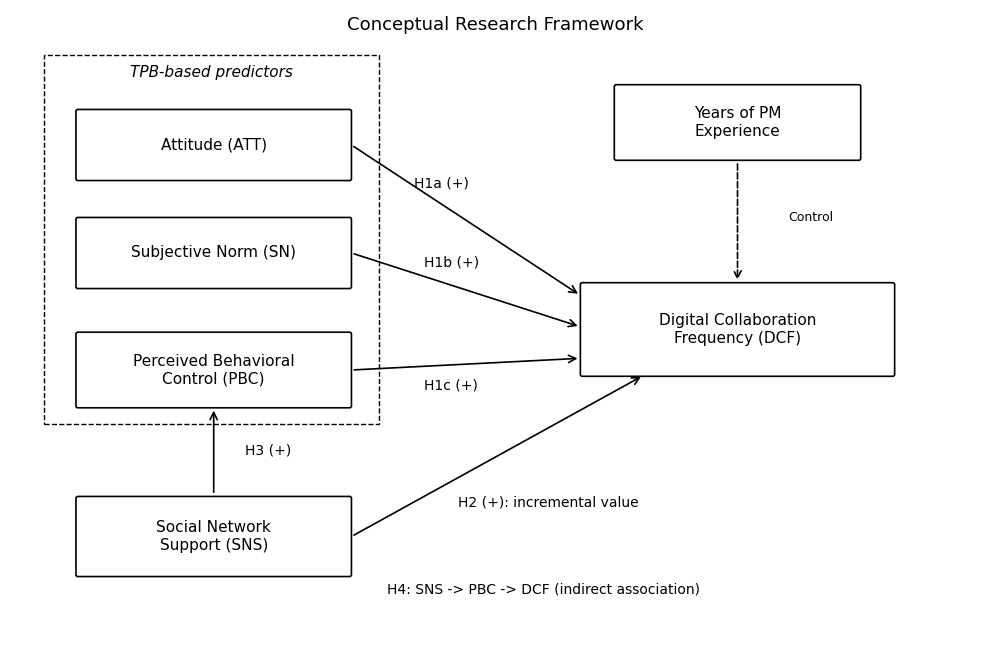

Saved: outputs_network_extended_tpb_revised\Figure1_conceptual_framework.png


In [11]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle

def diagram_box(ax, xy, width, height, text, fontsize=11):
    x, y = xy
    box = FancyBboxPatch((x-width/2, y-height/2), width, height,
                         boxstyle="round,pad=0.02", facecolor="white", linewidth=1.2)
    ax.add_patch(box)
    ax.text(x, y, text, ha="center", va="center", fontsize=fontsize)
    return box

def diagram_arrow(ax, start, end, style="->", dashed=False, curved=0):
    arrow = FancyArrowPatch(start, end, arrowstyle=style, mutation_scale=13,
                            linewidth=1.2, linestyle="--" if dashed else "-",
                            connectionstyle=f"arc3,rad={curved}")
    ax.add_patch(arrow)

fig, ax = plt.subplots(figsize=(10, 6.6))
ax.set(xlim=(0, 10), ylim=(0, 7)); ax.axis("off")
ax.add_patch(Rectangle((0.35, 2.4), 3.45, 4.1, fill=False, linestyle="--", linewidth=1))
ax.text(2.075, 6.25, "TPB-based predictors", ha="center", fontsize=11, fontstyle="italic")
diagram_box(ax, (2.1, 5.5), 2.8, 0.75, "Attitude (ATT)")
diagram_box(ax, (2.1, 4.3), 2.8, 0.75, "Subjective Norm (SN)")
diagram_box(ax, (2.1, 3.0), 2.8, 0.8, "Perceived Behavioral\nControl (PBC)")
diagram_box(ax, (2.1, 1.15), 2.8, 0.85, "Social Network\nSupport (SNS)")
diagram_box(ax, (7.5, 3.45), 3.2, 1.0, "Digital Collaboration\nFrequency (DCF)")
diagram_box(ax, (7.5, 5.75), 2.5, 0.8, "Years of PM\nExperience")
for start, end, txt, pos in [
    ((3.52,5.5),(5.88,3.83),"H1a (+)",(4.45,5.03)),
    ((3.52,4.3),(5.88,3.48),"H1b (+)",(4.55,4.15)),
    ((3.52,3.0),(5.88,3.13),"H1c (+)",(4.55,2.78)),
    ((3.52,1.15),(6.53,2.94),"H2 (+): incremental value",(5.55,1.48)),
    ((2.1,1.61),(2.1,2.58),"H3 (+)",(2.66,2.06)),
]:
    diagram_arrow(ax,start,end); ax.text(*pos,txt,ha="center",fontsize=10)
diagram_arrow(ax,(7.5,5.32),(7.5,3.97),dashed=True)
ax.text(8.02,4.65,"Control",fontsize=9)
ax.text(5.5,0.52,"H4: SNS -> PBC -> DCF (indirect association)",ha="center",fontsize=10)
ax.text(5.0,6.78,"Conceptual Research Framework",ha="center",fontsize=13)
fig.tight_layout()
figure1_path = OUTPUT_DIR / "Figure1_conceptual_framework.png"
fig.savefig(figure1_path, dpi=300, bbox_inches="tight")
fig.savefig(figure1_path.with_suffix(".svg"), bbox_inches="tight")
plt.show(); plt.close(fig)
print("Saved:", figure1_path)


## 10. Table 6, Panels A-B: Focused mediation SEM

The estimation is unchanged from v01: MLW with SLSQP, two latent three-item constructs (SNS and PBC), observed DCF and PM experience, and `SNS ~~ years_pm_experience`. Model fit and paths are combined in Table 6. H2's primary test remains the hierarchical-regression increment, not the direct path in this reduced SEM. ATT and SN are not included in the focused SEM; Part B separately examines covariate sensitivity.


In [12]:
def mediation_sem_description(free_exogenous_covariance=True):
    desc = """
    # Measurement model
    PBC =~ pbc_access_tools_num + pbc_self_efficacy_num + pbc_time_num
    SNS =~ support_has_colleague_help_num + team_discuss_tech_num + support_colleagues_try_new_num

    # Structural mediation model
    PBC ~ SNS + years_pm_experience
    digital_collaboration_num ~ SNS + PBC + years_pm_experience
    """
    if free_exogenous_covariance:
        desc += """
    # Free covariance between exogenous predictors; this is the manuscript SEM specification.
    SNS ~~ years_pm_experience
    """
    return desc

def fit_mediation_sem(df, free_exogenous_covariance=True):
    pbc_items = CONSTRUCT_ITEMS["PBC"]
    sns_items = CONSTRUCT_ITEMS["SNS"]
    sem_vars = pbc_items + sns_items + [OUTCOME_VAR, CONTROL_VAR]
    data = df[sem_vars].apply(pd.to_numeric, errors="coerce").dropna().copy()
    model = Model(mediation_sem_description(free_exogenous_covariance=free_exogenous_covariance))
    checked_sem_fit(model, data)
    fit = calc_stats(model)
    estimates = model.inspect(std_est=True)
    return model, data, fit, estimates

def get_sem_r2(estimates, variable):
    std = sem_std_col(estimates)
    row = estimates[(estimates["lval"] == variable) & (estimates["op"] == "~~") & (estimates["rval"] == variable)]
    residual_var = float(row[std].iloc[0])
    return 1 - residual_var

def summarize_sem_fit(fit, estimates, n):
    return {"N": n, "chi-square": fit_value(fit, "chi2"), "df": fit_value(fit, "DoF"), "chi-square p-value": fit_value(fit, "chi2 p-value"), "CFI": fit_value(fit, "CFI"), "TLI": fit_value(fit, "TLI"), "RMSEA": fit_value(fit, "RMSEA"), "R² for PBC": get_sem_r2(estimates, "PBC"), "R² for DCF": get_sem_r2(estimates, OUTCOME_VAR)}

sem_model, sem_data, sem_fit, sem_estimates = fit_mediation_sem(df, free_exogenous_covariance=True)
fit_summary = summarize_sem_fit(sem_fit, sem_estimates, len(sem_data))
table6_fit = pd.DataFrame({"Fit index": list(fit_summary.keys()), "Result": list(fit_summary.values())})

def sem_path_row(estimates, hypothesis, lhs, rhs, label):
    std = sem_std_col(estimates)
    pcol = sem_p_col(estimates)
    row = estimates[(estimates["lval"] == lhs) & (estimates["op"] == "~") & (estimates["rval"] == rhs)].iloc[0]
    beta = float(row[std])
    pval = float(row[pcol]) if pcol is not None and str(row[pcol]) != "-" else np.nan
    if hypothesis.startswith("H"):
        decision = "Supported" if pval < 0.05 else "Not supported"
    else:
        decision = "Significant" if pval < 0.05 else "Not significant"
    return {"Hypothesis": hypothesis, "Path": label, "Standardized β": beta, "p-value": pval, "Decision": decision}

path_specs = [("Association", OUTCOME_VAR, "SNS", "SNS -> DCF"),
              ("H3", "PBC", "SNS", "SNS -> PBC"),
              ("Association", OUTCOME_VAR, "PBC", "PBC -> DCF"),
              ("Control", "PBC", CONTROL_VAR, "PM experience -> PBC"),
              ("Control", OUTCOME_VAR, CONTROL_VAR, "PM experience -> DCF")]
table6_paths = pd.DataFrame([sem_path_row(sem_estimates, *spec) for spec in path_specs])
print("Complete SEM cases:", len(sem_data))
print(mediation_sem_description(True))
display(table6_fit.round(3))
display(table6_paths.assign(**{"Standardized β": table6_paths["Standardized β"].round(3),
                            "p-value": table6_paths["p-value"].map(p_value_text)}))


Complete SEM cases: 210

    # Measurement model
    PBC =~ pbc_access_tools_num + pbc_self_efficacy_num + pbc_time_num
    SNS =~ support_has_colleague_help_num + team_discuss_tech_num + support_colleagues_try_new_num

    # Structural mediation model
    PBC ~ SNS + years_pm_experience
    digital_collaboration_num ~ SNS + PBC + years_pm_experience
    
    # Free covariance between exogenous predictors; this is the manuscript SEM specification.
    SNS ~~ years_pm_experience
    


,Fit index,Result
0,N,210.000
1,chi-square,31.424
2,df,17.000
3,chi-square p-value,0.018
4,CFI,0.986
5,TLI,0.976
6,RMSEA,0.064
7,R² for PBC,0.521
8,R² for DCF,0.674


,Hypothesis,Path,Standardized β,p-value,Decision
0,Association,SNS -> DCF,0.655,< .001,Significant
1,H3,SNS -> PBC,0.717,< .001,Supported
2,Association,PBC -> DCF,0.224,0.002,Significant
3,Control,PM experience -> PBC,0.026,0.644,Not significant
4,Control,PM experience -> DCF,-0.091,0.033,Significant


## 11. Table 6, Panel C: Bootstrap composite mediation

This is the **unstandardized composite-score** mediation, with PM experience in both equations, 20,000 resamples, and seed 123. NumPy least squares replaces repeated DataFrame/statsmodels construction inside the resampling loop only; the regressions and random resampling order are the same. Progress is printed every 5,000 resamples. The sample is unchanged.

Percentile confidence intervals are calculated from the actual bootstrap distribution, not forced to match rounded values. The proportion mediated is a descriptive ratio of composite effects, not a percentage calculated from latent standardized paths. These cross-sectional associations do not identify a causal mediation effect.


In [13]:
data_comp = pd.DataFrame({"SNS_mean": df["SNS_mean"], "PBC_mean": df["PBC_mean"],
                          "DCF": df[OUTCOME_VAR], "PM_exp": df[CONTROL_VAR]}).copy()
mediator_model = sm.OLS(data_comp["PBC_mean"], sm.add_constant(data_comp[["SNS_mean", "PM_exp"]])).fit(cov_type="HC3")
outcome_model = sm.OLS(data_comp["DCF"], sm.add_constant(data_comp[["SNS_mean", "PBC_mean", "PM_exp"]])).fit(cov_type="HC3")

def composite_effects_array(a):
    """Columns: SNS, PBC, DCF, then controls. Same two OLS equations as v01."""
    intercept = np.ones(len(a))
    controls = a[:, 3:]
    X_m = np.column_stack([intercept, a[:, 0], controls])
    X_y = np.column_stack([intercept, a[:, 0], a[:, 1], controls])
    bm, _, rm, _ = np.linalg.lstsq(X_m, a[:, 1], rcond=None)
    by, _, ry, _ = np.linalg.lstsq(X_y, a[:, 2], rcond=None)
    if rm < X_m.shape[1] or ry < X_y.shape[1]:
        return np.full(6, np.nan)
    aa, bb, direct = bm[1], by[2], by[1]
    indirect = aa * bb
    total = direct + indirect
    proportion = indirect / total if abs(total) > 1e-12 else np.nan
    return np.array([aa, bb, direct, indirect, total, proportion])

EFFECT_NAMES = ["SNS -> PBC", "PBC -> DCF", "SNS -> DCF", "SNS -> PBC -> DCF", "Total effect", "Proportion mediated"]

def bootstrap_composite(data, controls, n_bootstrap=N_BOOTSTRAP, seed=RANDOM_SEED):
    """Paired row-resampling percentile bootstrap; controls enter both equations."""
    a = data[["SNS_mean", "PBC_mean", "DCF"] + controls].to_numpy(float)
    point = composite_effects_array(a)
    if not np.isfinite(point).all():
        raise ValueError("The composite mediation point estimate is undefined.")
    rng = np.random.default_rng(seed)
    draws = np.empty((n_bootstrap, 6))
    for b in range(n_bootstrap):
        sample = a[rng.integers(0, len(a), size=len(a))]
        draws[b] = composite_effects_array(sample)
        if (b + 1) % 5000 == 0:
            print(f"Bootstrap: {b+1:,}/{n_bootstrap:,}")
    valid = np.isfinite(draws).all(axis=1)
    if not valid.all():
        raise RuntimeError(f"{(~valid).sum()} undefined bootstrap draws; inspect the data/model rather than silently dropping them.")
    out = pd.DataFrame({"Effect": EFFECT_NAMES, "Estimate": point,
        "Bootstrap mean": draws.mean(axis=0), "95% Bootstrap CI lower": np.quantile(draws, .025, axis=0),
        "95% Bootstrap CI upper": np.quantile(draws, .975, axis=0)})
    out["Interpretation"] = np.where(
        (out["95% Bootstrap CI lower"] > 0) | (out["95% Bootstrap CI upper"] < 0),
        "CI excludes zero", "CI includes zero")
    out.loc[out["Effect"] == "Proportion mediated", "Interpretation"] = "Descriptive composite ratio"
    return out, pd.DataFrame(draws, columns=EFFECT_NAMES)

table6_bootstrap, boot_results = bootstrap_composite(data_comp, ["PM_exp"])
print("Composite mediation sample:", len(data_comp), "| Resamples:", N_BOOTSTRAP, "| Seed:", RANDOM_SEED)
display(table6_bootstrap.round(3))


Bootstrap: 5,000/20,000
Bootstrap: 10,000/20,000
Bootstrap: 15,000/20,000
Bootstrap: 20,000/20,000
Composite mediation sample: 210 | Resamples: 20000 | Seed: 123


,Effect,Estimate,Bootstrap mean,95% Bootstrap CI lower,95% Bootstrap CI upper,Interpretation
0,SNS -> PBC,0.567,0.565,0.430,0.697,CI excludes zero
1,PBC -> DCF,0.321,0.322,0.168,0.484,CI excludes zero
2,SNS -> DCF,0.642,0.640,0.479,0.786,CI excludes zero
3,SNS -> PBC -> DCF,0.182,0.183,0.086,0.301,CI excludes zero
4,Total effect,0.824,0.823,0.716,0.917,CI excludes zero
5,Proportion mediated,0.221,0.224,0.102,0.375,Descriptive composite ratio


## 12. Figure 2: Empirical focused mediation model

Coefficients and R-squared values are read from the fitted SEM. Both experience paths and the freely estimated exogenous covariance are shown. The figure displays standardized latent-SEM paths, not the composite bootstrap effects.


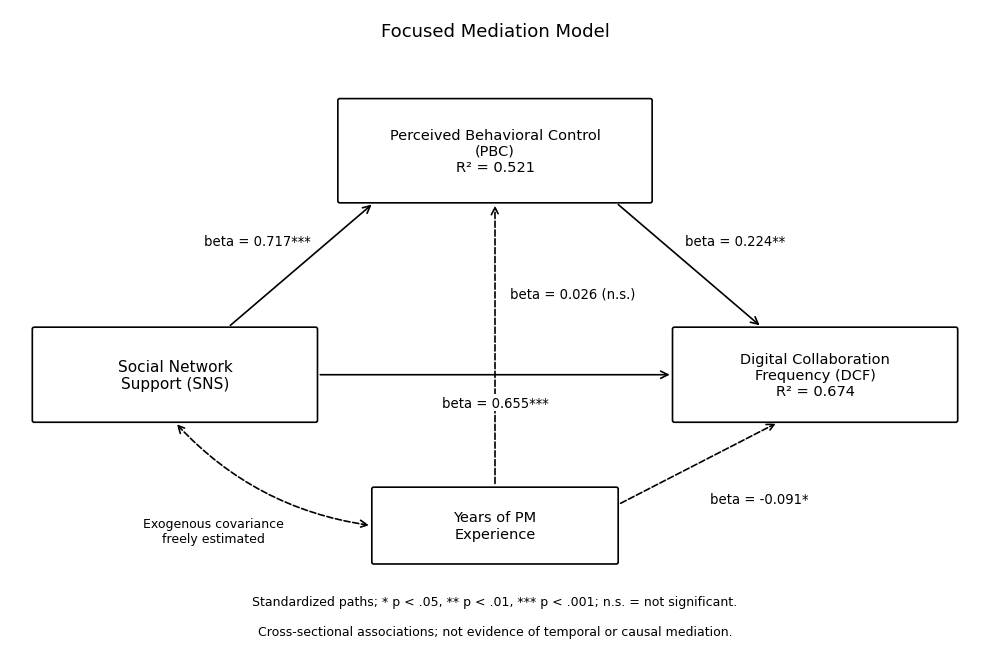

Saved: outputs_network_extended_tpb_revised\Figure2_empirical_mediation_model.png


In [14]:
std = sem_std_col(sem_estimates)
def get_std_path(lhs, rhs):
    row = sem_estimates[(sem_estimates["lval"] == lhs) & (sem_estimates["op"] == "~") & (sem_estimates["rval"] == rhs)].iloc[0]
    pval = float(row[sem_p_col(sem_estimates)])
    suffix = significance_stars(pval) if pval < .05 else " (n.s.)"
    return float(row[std]), suffix

sns_pbc, s1 = get_std_path("PBC", "SNS")
pbc_dcf, s2 = get_std_path(OUTCOME_VAR, "PBC")
sns_dcf, s3 = get_std_path(OUTCOME_VAR, "SNS")
pm_pbc, s4 = get_std_path("PBC", CONTROL_VAR)
pm_dcf, s5 = get_std_path(OUTCOME_VAR, CONTROL_VAR)
fig, ax = plt.subplots(figsize=(10, 6.7))
ax.set(xlim=(0, 10), ylim=(0, 7)); ax.axis("off")
diagram_box(ax,(1.7,3.0),2.9,1.0,"Social Network\nSupport (SNS)")
diagram_box(ax,(5,5.45),3.2,1.1,f"Perceived Behavioral Control\n(PBC)\nR² = {fit_summary['R² for PBC']:.3f}",10.5)
diagram_box(ax,(8.3,3.0),2.9,1.0,f"Digital Collaboration\nFrequency (DCF)\nR² = {fit_summary['R² for DCF']:.3f}",10.5)
diagram_box(ax,(5,1.35),2.5,.8,"Years of PM\nExperience",10.5)
for start,end,txt,pos,dashed in [
    ((2.25,3.52),(3.75,4.88),f"beta = {sns_pbc:.3f}{s1}",(2.55,4.42),False),
    ((6.25,4.88),(7.75,3.52),f"beta = {pbc_dcf:.3f}{s2}",(7.48,4.42),False),
    ((3.17,3),(6.83,3),f"beta = {sns_dcf:.3f}{s3}",(5,2.65),False),
    ((5,1.78),(5,4.88),f"beta = {pm_pbc:.3f}{s4}",(5.80,3.85),True),
    ((6.27,1.58),(7.92,2.48),f"beta = {pm_dcf:.3f}{s5}",(7.72,1.60),True),
]:
    diagram_arrow(ax,start,end,dashed=dashed)
    ax.text(*pos,txt,ha="center",fontsize=9.5,bbox=dict(facecolor="white",edgecolor="none",pad=1))
diagram_arrow(ax,(1.7,2.48),(3.73,1.35),style="<->",dashed=True,curved=.18)
ax.text(2.1,1.17,"Exogenous covariance\nfreely estimated",ha="center",fontsize=9)
ax.text(5,6.7,"Focused Mediation Model",ha="center",fontsize=13)
ax.text(5,.48,"Standardized paths; * p < .05, ** p < .01, *** p < .001; n.s. = not significant.",ha="center",fontsize=9)
ax.text(5,.15,"Cross-sectional associations; not evidence of temporal or causal mediation.",ha="center",fontsize=9)
fig.tight_layout()
figure2_path = OUTPUT_DIR / "Figure2_empirical_mediation_model.png"
fig.savefig(figure2_path,dpi=300,bbox_inches="tight")
fig.savefig(figure2_path.with_suffix(".svg"),bbox_inches="tight")
plt.show(); plt.close(fig)
print("Saved:",figure2_path)


## 13. Export the six tables and two figures

The Excel workbook has exactly six main-table sheets. Table 6 contains three panels (fit, standardized paths, unstandardized bootstrap effects). Unrounded estimates, full measurement-model parameters, regression diagnostics, settings, and data-file fingerprints are stored in `primary_details/`. No respondent-level data are exported. All reported statistics are calculated.


In [15]:
from openpyxl.styles import Font, Alignment, PatternFill

# One combined Table 6, with separately labeled scales and model types.
combined = []
for _, row in table6_fit.iterrows():
    value = float(row["Result"])
    idx = row["Fit index"]
    combined.append({"Panel / test": "A. Focused SEM fit", "Path or fit index": idx,
        "Estimate": f"{value:.0f}" if idx in {"N", "df"} else f"{value:.3f}",
        "p value / 95% CI": "", "Interpretation": "Focused two-factor mediation model"})
for _, row in table6_paths.iterrows():
    combined.append({"Panel / test": "B. Standardized SEM path", "Path or fit index": row["Path"],
        "Estimate": f"{row['Standardized β']:.3f}", "p value / 95% CI": p_value_text(row["p-value"]),
        "Interpretation": row["Decision"]})
for _, row in table6_bootstrap.iterrows():
    ratio = row["Effect"] == "Proportion mediated"
    combined.append({"Panel / test": "C. Composite bootstrap", "Path or fit index": row["Effect"],
        "Estimate": f"{100*row['Estimate']:.1f}%" if ratio else f"{row['Estimate']:.3f}",
        "p value / 95% CI": (f"[{100*row['95% Bootstrap CI lower']:.1f}%, {100*row['95% Bootstrap CI upper']:.1f}%]" if ratio else
                            f"[{row['95% Bootstrap CI lower']:.3f}, {row['95% Bootstrap CI upper']:.3f}]"),
        "Interpretation": row["Interpretation"]})
table6 = pd.DataFrame(combined)
main_tables = {
    "Table1_profile": table1, "Table2_items": table2_display,
    "Table3_reliability": table3.round(3),
    "Table4_correlations": table4_formatted.rename_axis("Construct").reset_index(),
    "Table5_regression": table5, "Table6_mediation": table6,
}

def write_excel_tables(path, tables):
    """Write computed results; modest formatting, no raw response rows."""
    with pd.ExcelWriter(path,engine="openpyxl") as writer:
        for i,(name,tab) in enumerate(tables.items(),1):
            sheet=name[:31]
            tab.to_excel(writer,sheet_name=sheet,index=False)
            ws=writer.book[sheet]; ws.freeze_panes="A2"; ws.sheet_view.showGridLines=False
            ws.auto_filter.ref=ws.dimensions
            for cell in ws[1]:
                cell.font=Font(bold=True,color="FFFFFF")
                cell.fill=PatternFill("solid",fgColor="243B53")
                cell.alignment=Alignment(wrap_text=True,vertical="center")
            ws.row_dimensions[1].height=32
            for col in ws.columns:
                values=[str(c.value or "") for c in col]
                width=min(58,max(14,max(map(len,values))+2))
                ws.column_dimensions[col[0].column_letter].width=width
                for c in col[1:]:
                    c.font=Font(color="000000",size=11)
                    c.alignment=Alignment(wrap_text=True,vertical="center")
                    if isinstance(c.value,float): c.number_format="0.000"
            for row in ws.iter_rows(min_row=2):
                lines=max(max(1,len(str(c.value or ""))//max(10,int(ws.column_dimensions[c.column_letter].width)-2)+1) for c in row)
                ws.row_dimensions[row[0].row].height=max(26,15*lines+8)

output_excel = OUTPUT_DIR / "Tables_1_to_6.xlsx"
write_excel_tables(output_excel,main_tables)
for name,table in main_tables.items():
    table.to_csv(OUTPUT_DIR/(name+".csv"),index=False,encoding="utf-8-sig")
primary_details={"regression_model_summary":model_summary_table,
    "regression_coefficients":detailed_regression_table,"VIF_model3":vif_model3,
    "measurement_CFA_fit":measurement_fit_summary,"measurement_CFA_estimates":measurement_estimates,
    "reliability_unrounded":table3_unrounded,"correlations_full":corr.rename_axis("Construct").reset_index(),
    "SEM_fit":table6_fit,"SEM_paths":table6_paths,"SEM_estimates":sem_estimates,
    "bootstrap_composite":table6_bootstrap,"descriptives_unrounded":table2}
for name,table in primary_details.items():
    table.to_csv(DETAILS_DIR/(name+".csv"),index=False,encoding="utf-8-sig")
from importlib.metadata import version, PackageNotFoundError
versions={}
for package in required_packages.values():
    try: versions[package]=version(package)
    except PackageNotFoundError: versions[package]="unavailable"
run_metadata={"title":"Network-Extended Theory of Planned Behavior for Digital Collaboration in Construction Project Management",
    "source":"Google Drive/Sheets", "file_id":GOOGLE_SHEETS_FILE_ID,"sheet":sheet_to_read,
    "downloaded_file_sha256":globals().get("DATA_FILE_SHA256","not recorded"),
    "numeric_data_sha256":hashlib.sha256(df[required_columns].to_csv(index=False,float_format="%.12g").encode()).hexdigest(),
    "rows_loaded":int(input_n),"analysis_N":len(df),"incomplete_rows_excluded":int(input_n-len(df)),
    "bootstrap_N":N_BOOTSTRAP,"bootstrap_seed":RANDOM_SEED,
    "supplementary_enabled":RUN_SUPPLEMENTARY,"diagnostic_bootstrap_N":N_DIAGNOSTIC_BOOTSTRAP,
    "diagnostic_seed":DIAGNOSTIC_SEED,"SEM":"semopy MLW/SLSQP; original default tolerances",
    "python":platform.python_version(),"packages":versions}
(OUTPUT_DIR/"run_metadata.json").write_text(json.dumps(run_metadata,indent=2),encoding="utf-8")
print("Primary analysis complete.")
print("Six-table workbook:",output_excel.resolve())
print("Figures:",figure1_path.name,"and",figure2_path.name)


Primary analysis complete.
Six-table workbook: C:\Users\lnguyen\OneDrive - Florida Gulf Coast University\AAA\FGCU\Courses\Thesis\NguyenDucTuan2024\FromTuan\20260424\Revision1\outputs_network_extended_tpb_revised\Tables_1_to_6.xlsx
Figures: Figure1_conceptual_framework.png and Figure2_empirical_mediation_model.png


## 14. Primary numerical consistency checks

These are checks against previously reported rounded values, not fixed results. A difference is displayed for investigation, never overwritten. Software tolerances or an edited Drive workbook can affect the comparison. The corrected F-tests and recalculated bootstrap endpoints supersede the previously mixed F-test row and rounded intervals.


In [16]:
expected = {
    "Table 5 Model 1 R²": 0.455,
    "Table 5 Model 2 R²": 0.623,
    "Table 5 Model 3 R²": 0.632,
    "Table 6 SEM df": 17,
    "Table 6 SEM CFI": 0.986,
    "Table 6 SEM TLI": 0.976,
    "Table 6 SEM RMSEA": 0.064,
}
observed = {
    "Table 5 Model 1 R²": model_summary_table.loc[0, "R²"],
    "Table 5 Model 2 R²": model_summary_table.loc[1, "R²"],
    "Table 5 Model 3 R²": model_summary_table.loc[2, "R²"],
    "Table 6 SEM df": fit_summary["df"],
    "Table 6 SEM CFI": fit_summary["CFI"],
    "Table 6 SEM TLI": fit_summary["TLI"],
    "Table 6 SEM RMSEA": fit_summary["RMSEA"],
}
consistency = pd.DataFrame({"Statistic": observed.keys(), "Observed": observed.values(), "Expected manuscript value": [expected[k] for k in observed.keys()]})
consistency["Difference"] = consistency["Observed"] - consistency["Expected manuscript value"]

consistency["Within rounding tolerance"] = consistency["Difference"].abs() <= 0.0005
display(consistency.round(5))
consistency.to_csv(DETAILS_DIR / "primary_consistency_checks.csv",index=False,encoding="utf-8-sig")


,Statistic,Observed,Expected manuscript value,Difference,Within rounding tolerance
0,Table 5 Model 1 R²,0.45535,0.455,0.00035,True
1,Table 5 Model 2 R²,0.62323,0.623,0.00023,True
2,Table 5 Model 3 R²,0.63208,0.632,0.00008,True
3,Table 6 SEM df,17.00000,17.000,0.00000,True
4,Table 6 SEM CFI,0.98604,0.986,0.00004,True
5,Table 6 SEM TLI,0.97619,0.976,0.00019,True
6,Table 6 SEM RMSEA,0.06371,0.064,-0.00029,True


# Part B. Supplementary analyses (post hoc)

These sections use the prepared data and fitted models from Part A. They do not require another notebook or any external source files. All numerical results are generated afresh and saved in `supplementary/`, separately from Tables 1-6.

**Interpretation:** HTMT/alternative-CFA checks assess measurement separation; they do not repair item wording. A poorly fitting single-factor model does not rule out common-method bias. Item omissions are sensitivity analyses, not validated replacement scales. Cross-sectional covariate adjustment cannot resolve endogeneity or establish causality. Sparse occupational groups do not support equivalence or measurement-invariance claims. Unfavorable or materially different results are acknowledged in the paper.

Set `RUN_SUPPLEMENTARY = False` in the original settings cell to skip this part when only the six primary tables and two figures are needed.

## S1. HTMT, actual latent correlations, and alternative measurement models

HTMT uses absolute item correlations and paired row resampling. Both a two-sided 95% interval and a one-sided 95% upper bound are reported. Alternative models use the same 12 items and sample. Merged-factor fit comparisons are descriptive; a regular chi-square difference test is not assumed at the correlation-equals-one boundary.


In [17]:
supplementary_tables = {}

def htmt_values(a, blocks):
    """HTMT for equally oriented items, using absolute Pearson correlations."""
    columns=[item for items in blocks.values() for item in items]
    ix={name:i for i,name in enumerate(columns)}
    r=np.abs(np.corrcoef(a,rowvar=False)); values=[]
    for f1,f2 in combinations(blocks,2):
        i=[ix[c] for c in blocks[f1]]; j=[ix[c] for c in blocks[f2]]
        within_i=r[np.ix_(i,i)][np.triu_indices(len(i),1)].mean()
        within_j=r[np.ix_(j,j)][np.triu_indices(len(j),1)].mean()
        values.append(r[np.ix_(i,j)].mean()/np.sqrt(within_i*within_j))
    return np.asarray(values)

def cfa_from_blocks(blocks):
    syntax="\n".join(f"{name} =~ " + " + ".join(items) for name,items in blocks.items())
    model=Model(syntax)
    columns=[c for items in blocks.values() for c in items]
    checked_sem_fit(model,df[columns])
    return model,calc_stats(model)

if RUN_SUPPLEMENTARY:
    items=[x for v in CONSTRUCT_ITEMS.values() for x in v]
    a=df[items].to_numpy(float)
    rng=np.random.default_rng(DIAGNOSTIC_SEED)
    htmt_draws=np.empty((N_DIAGNOSTIC_BOOTSTRAP,6))
    for b in range(N_DIAGNOSTIC_BOOTSTRAP):
        htmt_draws[b]=htmt_values(a[rng.integers(0,len(a),size=len(a))],CONSTRUCT_ITEMS)
    valid=np.isfinite(htmt_draws).all(axis=1)
    if not valid.all():
        raise RuntimeError(f"Undefined HTMT in {(~valid).sum()} draws; inspect before reporting.")
    htmt_table=pd.DataFrame({
        "Pair":[f"{x} - {y}" for x,y in combinations(CONSTRUCT_ITEMS,2)],
        "HTMT":htmt_values(a,CONSTRUCT_ITEMS),
        "95% CI lower":np.quantile(htmt_draws,.025,axis=0),
        "95% CI upper":np.quantile(htmt_draws,.975,axis=0),
        "One-sided 95% upper":np.quantile(htmt_draws,.95,axis=0),
        "Resamples":N_DIAGNOSTIC_BOOTSTRAP,"Seed":DIAGNOSTIC_SEED})
    htmt_table["Point below .85"]=htmt_table["HTMT"]<.85
    htmt_table["Point below .90"]=htmt_table["HTMT"]<.90
    htmt_table["Two-sided upper below 1"]=htmt_table["95% CI upper"]<1
    supplementary_tables["S01_HTMT"]=htmt_table
    print("HTMT (thresholds are diagnostics, not automatic validation):")
    display(htmt_table.round(3))

    latent_rows=[]
    latent_r=pd.DataFrame(np.eye(4),index=list(CONSTRUCT_ITEMS),columns=list(CONSTRUCT_ITEMS))
    ave=table3_unrounded.set_index("Construct")["AVE"]
    for f1,f2 in combinations(CONSTRUCT_ITEMS,2):
        match=measurement_estimates[(measurement_estimates["op"]=="~~") & (
            ((measurement_estimates["lval"]==f1)&(measurement_estimates["rval"]==f2)) |
            ((measurement_estimates["lval"]==f2)&(measurement_estimates["rval"]==f1)))]
        if len(match)!=1: raise ValueError(f"Cannot identify latent covariance {f1} - {f2}.")
        r=float(match[std_col].iloc[0])
        latent_r.loc[f1,f2]=latent_r.loc[f2,f1]=r
        latent_rows.append({"Pair":f"{f1} - {f2}","Latent correlation":r,
            "sqrt AVE 1":np.sqrt(ave[f1]),"sqrt AVE 2":np.sqrt(ave[f2]),
            "Both sqrt AVE exceed absolute latent r":bool(min(np.sqrt(ave[f1]),np.sqrt(ave[f2]))>abs(r))})
    supplementary_tables["S02_latent_validity"]=pd.DataFrame(latent_rows)
    supplementary_tables["S03_latent_correlations"]=latent_r.rename_axis("Construct").reset_index()
    display(supplementary_tables["S02_latent_validity"].round(3))

    alternative_blocks={
        "SN and SNS combined":{"ATT":CONSTRUCT_ITEMS["ATT"],"PBC":CONSTRUCT_ITEMS["PBC"],
                               "SN_SNS":CONSTRUCT_ITEMS["SN"]+CONSTRUCT_ITEMS["SNS"]},
        "ATT, SN and PBC combined":{"TPB":CONSTRUCT_ITEMS["ATT"]+CONSTRUCT_ITEMS["SN"]+CONSTRUCT_ITEMS["PBC"],
                                    "SNS":CONSTRUCT_ITEMS["SNS"]},
        "One factor (12 predictor items)":{"GENERAL":items},
    }
    for f1,f2 in [("ATT","SN"),("ATT","PBC"),("SN","PBC")]:
        blocks={k:list(v) for k,v in CONSTRUCT_ITEMS.items() if k not in {f1,f2}}
        blocks[f1+"_"+f2]=CONSTRUCT_ITEMS[f1]+CONSTRUCT_ITEMS[f2]
        alternative_blocks[f"{f1} and {f2} combined"]=blocks
    comparison=[{**measurement_fit_summary.iloc[0].to_dict(),"Status":"Converged"}]
    for name,blocks in alternative_blocks.items():
        try:
            alt,fit=cfa_from_blocks(blocks)
            estimates=alt.inspect(std_est=True)
            negative=estimates[(estimates["op"]=="~~") & (estimates["lval"]==estimates["rval"])]["Estimate"].astype(float).lt(-1e-8).any()
            comparison.append({"Model":name,"N":len(df),"chi-square":fit_value(fit,"chi2"),
                "df":fit_value(fit,"DoF"),"CFI":fit_value(fit,"CFI"),"TLI":fit_value(fit,"TLI"),
                "RMSEA":fit_value(fit,"RMSEA"),"Status":"Negative variance; inspect" if negative else "Converged"})
        except Exception as exc:
            comparison.append({"Model":name,"N":len(df),"Status":"FAILED: "+str(exc)})
            warnings.warn(f"Alternative CFA {name} failed: {exc}")
    cfa_comparisons=pd.DataFrame(comparison)
    cfa_comparisons["Descriptive delta chi-square"]=cfa_comparisons["chi-square"]-fit_value(measurement_fit,"chi2")
    supplementary_tables["S04_CFA_comparisons"]=cfa_comparisons
    display(cfa_comparisons.round(3))

    eig=np.linalg.eigvalsh(np.corrcoef(a,rowvar=False))
    cmv_summary=pd.DataFrame([{"Diagnostic":"First unrotated principal component of 12 predictor items",
        "Percent item variance":100*eig[-1]/eig.sum(),
        "Interpretation":"Descriptive PCA only; neither this nor the one-factor CFA can exclude common-method bias."}])
    supplementary_tables["S05_same_source_checks"]=cmv_summary
    display(cmv_summary)
else:
    print("Part B skipped. Primary tables and figures are already saved.")


HTMT (thresholds are diagnostics, not automatic validation):


,Pair,HTMT,95% CI lower,95% CI upper,One-sided 95% upper,Resamples,Seed,Point below .85,Point below .90,Two-sided upper below 1
0,ATT - SN,0.903,0.816,0.959,0.952,10000,20260915,False,False,True
1,ATT - PBC,0.893,0.805,0.950,0.942,10000,20260915,False,True,True
2,ATT - SNS,0.588,0.427,0.711,0.692,10000,20260915,True,True,True
3,SN - PBC,0.904,0.808,0.971,0.961,10000,20260915,False,False,True
4,SN - SNS,0.729,0.615,0.823,0.810,10000,20260915,True,True,True
5,PBC - SNS,0.763,0.655,0.849,0.837,10000,20260915,True,True,True


,Pair,Latent correlation,sqrt AVE 1,sqrt AVE 2,Both sqrt AVE exceed absolute latent r
0,ATT - SN,0.891,0.865,0.847,False
1,ATT - PBC,0.901,0.865,0.833,False
2,ATT - SNS,0.569,0.865,0.853,True
3,SN - PBC,0.895,0.847,0.833,False
4,SN - SNS,0.709,0.847,0.853,True
5,PBC - SNS,0.720,0.833,0.853,True


,Model,N,chi-square,df,CFI,TLI,RMSEA,Status,Descriptive delta chi-square
0,Four-factor predictor CFA,210,136.985,48.0,0.958,0.942,0.094,Converged,0.000
1,SN and SNS combined,210,329.004,51.0,0.868,0.829,0.161,Converged,192.019
2,"ATT, SN and PBC combined",210,217.968,53.0,0.922,0.903,0.122,Converged,80.982
3,One factor (12 predictor items),210,420.582,54.0,0.826,0.787,0.180,Converged,283.597
4,ATT and SN combined,210,186.770,51.0,0.936,0.917,0.113,Converged,49.785
5,ATT and PBC combined,210,185.406,51.0,0.936,0.917,0.112,Converged,48.421
6,SN and PBC combined,210,166.538,51.0,0.945,0.929,0.104,Converged,29.553


,Diagnostic,Percent item variance,Interpretation
0,First unrotated principal component of 12 pred...,63.185986,Descriptive PCA only; neither this nor the one...


## S2. Sensitivity to potentially overlapping SN2 and SNS3 items

Refit the full composite regression after omitting SN2, SNS3, or both. Keep all observations, ATT/PBC definitions, controls, and scaling rules unchanged. Report the SNS increment after the other predictors, including experience; this is different from the original H2 increment before adding experience. The original three-item scales remain the primary measures.


In [18]:
if RUN_SUPPLEMENTARY:
    sn=CONSTRUCT_ITEMS["SN"]; sns=CONSTRUCT_ITEMS["SNS"]
    scenarios={"Original items":(sn,sns),"Omit SN2":([sn[0],sn[2]],sns),
               "Omit SNS3":(sn,sns[:2]),"Omit SN2 and SNS3":([sn[0],sn[2]],sns[:2])}
    omission_rows=[]
    for name,(sn_items,sns_items) in scenarios.items():
        tmp=reg_data.copy()
        tmp["SN"]=df[sn_items].mean(axis=1); tmp["SNS"]=df[sns_items].mean(axis=1)
        reduced=fit_composite_regression(tmp,["ATT","SN","PBC","PM_exp"])
        full=fit_composite_regression(tmp,predictor_order)
        omission_rows.append({"Scenario":name,"N":len(tmp),"SN items":len(sn_items),"SNS items":len(sns_items),
            "Alpha SN":cronbach_alpha(df[sn_items]),"Alpha SNS":cronbach_alpha(df[sns_items]),
            "SN-SNS HTMT":htmt_values(df[sn_items+sns_items].to_numpy(float),{"SN":sn_items,"SNS":sns_items})[0],
            "SNS beta":full.params["SNS"],"SNS HC3 SE":full.bse["SNS"],"SNS HC3 p":full.pvalues["SNS"],
            "SN beta":full.params["SN"],"SN HC3 p":full.pvalues["SN"],
            "Full R2":full.rsquared,"SNS unique delta R2":full.rsquared-reduced.rsquared})
    supplementary_tables["S06_item_omissions"]=pd.DataFrame(omission_rows)
    display(supplementary_tables["S06_item_omissions"].round(4))


,Scenario,N,SN items,SNS items,Alpha SN,Alpha SNS,SN-SNS HTMT,SNS beta,SNS HC3 SE,SNS HC3 p,SN beta,SN HC3 p,Full R2,SNS unique delta R2
0,Original items,210,3,3,0.8794,0.8834,0.7292,0.5882,0.0857,0.0,0.0864,0.4578,0.6321,0.1733
1,Omit SN2,210,2,3,0.7656,0.8834,0.7704,0.5807,0.0865,0.0,0.1231,0.2462,0.6343,0.1696
2,Omit SNS3,210,3,2,0.8794,0.7824,0.7689,0.5400,0.0877,0.0,0.0985,0.4195,0.6078,0.1491
3,Omit SN2 and SNS3,210,2,2,0.7656,0.7824,0.8088,0.5322,0.0886,0.0,0.1411,0.2148,0.6107,0.1461


## S3. Unique/shared variance, coefficient stability, and attitude interpretation

Dropping each predictor from the full model estimates its unique increment. ATT, SN and PBC are also tested **jointly**, to avoid interpreting nonsignificant individual coefficients as replacement of TPB. Bootstrap coefficient intervals standardize within each resample. The fraction of positive bootstrap coefficients is descriptive, **not a p-value**. High mean or ceiling percentages alone do not explain causally why ATT is nonsignificant.


In [19]:
if RUN_SUPPLEMENTARY:
    full=models["Model 3: TPB + SNS + Control"]
    unique_rows=[]
    for names in [[p] for p in predictor_order]+[["ATT","SN","PBC"]]:
        reduced=fit_composite_regression(reg_data,[p for p in predictor_order if p not in names])
        delta=full.rsquared-reduced.rsquared
        fw,pw=hc3_block_test(full,names)
        unique_rows.append({"Predictor/block":" + ".join(names),"Unique delta R2":delta,
            "Partial R2":delta/(1-reduced.rsquared),"Cohen f2":delta/(1-full.rsquared),
            "HC3 Wald F":fw,"HC3 Wald p":pw})
    supplementary_tables["S07_unique_variance"]=pd.DataFrame(unique_rows)
    display(supplementary_tables["S07_unique_variance"].round(4))

    X=sm.add_constant(reg_data_std[predictor_order]).to_numpy(float)
    sv=np.linalg.svd(X/np.sqrt((X*X).sum(axis=0)),compute_uv=False)
    supplementary_tables["S08_condition_indices"]=pd.DataFrame({"Dimension":np.arange(1,len(sv)+1),"Condition index":sv.max()/sv})
    a=reg_data[predictor_order+["DCF"]].to_numpy(float)
    specs=[("Model 1",[0,1,2]),("Model 2",[0,1,2,3]),("Model 3",[0,1,2,3,4])]
    keys=[(name,predictor_order[i]) for name,ix in specs for i in ix]
    rng=np.random.default_rng(DIAGNOSTIC_SEED+1)
    coef_boot=np.empty((N_DIAGNOSTIC_BOOTSTRAP,len(keys)))
    for b in range(N_DIAGNOSTIC_BOOTSTRAP):
        sample=a[rng.integers(0,len(a),size=len(a))]
        sd=sample.std(axis=0,ddof=0)
        if (sd==0).any(): raise RuntimeError("Constant variable in coefficient bootstrap draw.")
        sample=(sample-sample.mean(axis=0))/sd
        values=[]
        for name,ix in specs:
            design=np.column_stack([np.ones(len(a)),sample[:,ix]])
            beta,_,rank,_=np.linalg.lstsq(design,sample[:,-1],rcond=None)
            if rank!=design.shape[1]: raise RuntimeError("Rank-deficient coefficient bootstrap draw.")
            values.extend(beta[1:])
        coef_boot[b]=values
    supplementary_tables["S09_coefficient_stability"]=pd.DataFrame({
        "Model":[x[0] for x in keys],"Predictor":[x[1] for x in keys],
        "Bootstrap mean":coef_boot.mean(axis=0),"95% CI lower":np.quantile(coef_boot,.025,axis=0),
        "95% CI upper":np.quantile(coef_boot,.975,axis=0),
        "Fraction positive (not p)":(coef_boot>0).mean(axis=0),"Resamples":N_DIAGNOSTIC_BOOTSTRAP})
    display(supplementary_tables["S09_coefficient_stability"].round(3))
    attitude_rows=[]
    for col in ["ATT_mean"]+CONSTRUCT_ITEMS["ATT"]:
        x=df[col]
        attitude_rows.append({"Variable":col,"Mean":x.mean(),"SD":x.std(ddof=1),
            "% exactly 5":100*x.eq(5).mean(),"% at least 4":100*x.ge(4).mean(),"Min":x.min(),"Max":x.max()})
    supplementary_tables["S10_attitude_distribution"]=pd.DataFrame(attitude_rows)
    attitude_models=[]
    for name,preds in [("ATT alone",["ATT"]),("ATT + SN",["ATT","SN"]),("ATT + PBC",["ATT","PBC"]),
                       ("TPB",["ATT","SN","PBC"]),("TPB + SNS",["ATT","SN","PBC","SNS"]),("Full",predictor_order)]:
        fit=fit_composite_regression(reg_data,preds)
        attitude_models.append({"Model":name,"ATT beta":fit.params["ATT"],"ATT HC3 SE":fit.bse["ATT"],
                               "ATT HC3 p":fit.pvalues["ATT"],"R2":fit.rsquared})
    supplementary_tables["S11_attitude_models"]=pd.DataFrame(attitude_models)
    display(supplementary_tables["S11_attitude_models"].round(4))


,Predictor/block,Unique delta R2,Partial R2,Cohen f2,HC3 Wald F,HC3 Wald p
0,ATT,0.0011,0.0030,0.0030,0.4124,0.5215
1,SN,0.0020,0.0054,0.0054,0.5514,0.4586
2,PBC,0.0064,0.0171,0.0174,2.4272,0.1208
3,SNS,0.1733,0.3202,0.4711,47.0836,0.0000
4,PM_exp,0.0088,0.0235,0.0240,3.3173,0.0700
5,ATT + SN + PBC,0.0426,0.1038,0.1158,6.0507,0.0006


,Model,Predictor,Bootstrap mean,95% CI lower,95% CI upper,Fraction positive (not p),Resamples
0,Model 1,ATT,-0.049,-0.257,0.164,0.322,10000
1,Model 1,SN,0.310,0.094,0.543,0.998,10000
2,Model 1,PBC,0.442,0.242,0.642,1.000,10000
3,Model 2,ATT,0.063,-0.119,0.246,0.755,10000
4,Model 2,SN,0.080,-0.129,0.308,0.750,10000
5,Model 2,PBC,0.154,-0.027,0.341,0.951,10000
6,Model 2,SNS,0.573,0.408,0.717,1.000,10000
7,Model 3,ATT,0.062,-0.118,0.243,0.749,10000
8,Model 3,SN,0.087,-0.116,0.304,0.786,10000
9,Model 3,PBC,0.155,-0.028,0.345,0.950,10000


,Model,ATT beta,ATT HC3 SE,ATT HC3 p,R2
0,ATT alone,0.5485,0.0555,0.0000,0.3009
1,ATT + SN,0.1429,0.1190,0.2297,0.3923
2,ATT + PBC,0.1003,0.0942,0.2871,0.4280
3,TPB,-0.0466,0.1121,0.6779,0.4553
4,TPB + SNS,0.0659,0.0959,0.4919,0.6232
5,Full,0.0617,0.0960,0.5208,0.6321


## S4. Composite mediation with additional ATT and SN covariates

This **post hoc** model adds ATT and SN to both composite equations alongside experience. It does not replace the focused SEM or the primary bootstrap. Compare unstandardized composite effects with unstandardized composite effects. An interval including zero is a substantive qualification, not an execution failure. Neither specification establishes causality from cross-sectional data.


In [20]:
if RUN_SUPPLEMENTARY:
    adjusted_data=data_comp.copy()
    adjusted_data["ATT"]=df["ATT_mean"]; adjusted_data["SN"]=df["SN_mean"]
    adjusted_mediation,_=bootstrap_composite(adjusted_data,["PM_exp","ATT","SN"])
    mediation_comparison=pd.concat([
        table6_bootstrap.assign(Specification="Primary: PM experience"),
        adjusted_mediation.assign(Specification="Post hoc: PM experience + ATT + SN")],ignore_index=True)
    supplementary_tables["S12_adjusted_mediation"]=mediation_comparison
    display(mediation_comparison.round(4))
    indirect=adjusted_mediation.loc[adjusted_mediation["Effect"]=="SNS -> PBC -> DCF"].iloc[0]
    if indirect["95% Bootstrap CI lower"]<=0<=indirect["95% Bootstrap CI upper"]:
        print("Interpretation: the adjusted indirect-effect CI includes zero; the mediation finding is covariate-sensitive.")


Bootstrap: 5,000/20,000
Bootstrap: 10,000/20,000
Bootstrap: 15,000/20,000
Bootstrap: 20,000/20,000


,Effect,Estimate,Bootstrap mean,95% Bootstrap CI lower,95% Bootstrap CI upper,Interpretation,Specification
0,SNS -> PBC,0.5675,0.5652,0.4298,0.6972,CI excludes zero,Primary: PM experience
1,PBC -> DCF,0.3208,0.3216,0.1683,0.4843,CI excludes zero,Primary: PM experience
2,SNS -> DCF,0.6423,0.6403,0.4791,0.7856,CI excludes zero,Primary: PM experience
3,SNS -> PBC -> DCF,0.1821,0.1831,0.0857,0.3013,CI excludes zero,Primary: PM experience
4,Total effect,0.8244,0.8234,0.7157,0.9165,CI excludes zero,Primary: PM experience
5,Proportion mediated,0.2208,0.2235,0.1021,0.3754,Descriptive composite ratio,Primary: PM experience
6,SNS -> PBC,0.2334,0.2333,0.1453,0.3265,CI excludes zero,Post hoc: PM experience + ATT + SN
7,PBC -> DCF,0.1910,0.1932,-0.0372,0.4287,CI includes zero,Post hoc: PM experience + ATT + SN
8,SNS -> DCF,0.6238,0.6213,0.4441,0.7783,CI excludes zero,Post hoc: PM experience + ATT + SN
9,SNS -> PBC -> DCF,0.0446,0.0458,-0.0081,0.1138,CI includes zero,Post hoc: PM experience + ATT + SN


Interpretation: the adjusted indirect-effect CI includes zero; the mediation finding is covariate-sensitive.


## S5. Exploratory occupational-role differences

The original broad categories reproduce Table 1. For the combined design/engineering/BIM/QS group, role titles are disaggregated using outcome-blind keyword rules. Mixed or unidentified specialist titles are not forced into a subgroup. Moments are suppressed for groups smaller than five; inferential comparisons require at least ten observations in each included group. This threshold is not a power calculation. Rank tests compare distributions and do not establish equivalent occupations. The broad-role-adjusted regression is separate from the primary model.


In [21]:
def specialist_role(title):
    key=normalize_category_key(title)
    if key==normalize_category_key(ROLE_ORDER[0]):
        return "Broad category only - specialization unknown"
    hits=[]
    if re.search(r"\bbim\b",key): hits.append("BIM")
    if re.search(r"\bqs\b|quantity survey|estimat|cost.contract",key): hits.append("QS / estimating")
    if re.search(r"design|architect",key): hits.append("Design / architecture")
    if len(hits)>1: return "Mixed specialist roles"
    if hits: return hits[0]
    if re.search(r"engineer|engineering|structur|\bmep\w*\b|\bcad\b|draft",key):
        return "Engineering - general / other"
    return "Not an identified specialist"

if RUN_SUPPLEMENTARY:
    from scipy.stats import kruskal, mannwhitneyu
    from statsmodels.stats.multitest import multipletests
    role_data=reg_data.copy()
    role_data["Broad role"]=df["role_category"]
    role_data["Specialist"]=df.get("job_title",pd.Series("",index=df.index)).map(specialist_role)
    desc_rows=[]; omnibus_rows=[]; pairwise_rows=[]
    for scope,col,sub in [
        ("Broad roles","Broad role",role_data),
        ("Disaggregated design/engineering/BIM/QS","Specialist",role_data.loc[role_data["Broad role"]==ROLE_ORDER[0]])]:
        counts=sub[col].value_counts()
        allowed=[g for g,n in counts.items() if n>=MIN_ROLE_N and not any(x in g.lower() for x in ["unknown","mixed","not an identified"])]
        for group,g in sub.groupby(col,observed=True):
            for outcome in ["SNS","DCF"]:
                desc_rows.append({"Scope":scope,"Group":group,"Outcome":outcome,"N":len(g),
                    "Mean":g[outcome].mean() if len(g)>=5 else np.nan,
                    "SD":g[outcome].std(ddof=1) if len(g)>=5 else np.nan,
                    "Median":g[outcome].median() if len(g)>=5 else np.nan,
                    "Eligible for comparison":group in allowed})
        for outcome in ["SNS","DCF"]:
            if len(allowed)<2:
                omnibus_rows.append({"Scope":scope,"Outcome":outcome,"p":np.nan,"Status":"Too few sufficiently populated identifiable groups"})
                continue
            samples=[sub.loc[sub[col]==g,outcome].to_numpy(float) for g in allowed]
            h,p=kruskal(*samples); total=sum(map(len,samples)); k=len(samples)
            omnibus_rows.append({"Scope":scope,"Outcome":outcome,"Groups":"; ".join(allowed),
                "N tested":total,"H":h,"df":k-1,"p":p,"Rank epsilon squared":max(0,(h-k+1)/(total-k)),
                "Status":"Exploratory rank-distribution test"})
            pr=[]
            for g1,g2 in combinations(allowed,2):
                x=sub.loc[sub[col]==g1,outcome]; y=sub.loc[sub[col]==g2,outcome]
                u,pp=mannwhitneyu(x,y,alternative="two-sided",method="asymptotic")
                pr.append({"Scope":scope,"Outcome":outcome,"Group 1":g1,"Group 2":g2,"N1":len(x),"N2":len(y),
                    "U":u,"Unadjusted p":pp,"Rank biserial":2*u/(len(x)*len(y))-1})
            adj=multipletests([r["Unadjusted p"] for r in pr],method="holm")[1]
            for row,pp in zip(pr,adj): row["Holm p (within scope/outcome)"]=pp
            pairwise_rows.extend(pr)
    omnibus=pd.DataFrame(omnibus_rows); valid=omnibus["p"].notna()
    omnibus["Holm p (all omnibus)"]=np.nan
    if valid.any(): omnibus.loc[valid,"Holm p (all omnibus)"]=multipletests(omnibus.loc[valid,"p"],method="holm")[1]
    supplementary_tables["S13_role_descriptives"]=pd.DataFrame(desc_rows)
    supplementary_tables["S14_role_omnibus"]=omnibus
    supplementary_tables["S15_role_pairwise"]=pd.DataFrame(pairwise_rows)
    display(supplementary_tables["S13_role_descriptives"].round(3))
    display(omnibus.round(4))

    categories=pd.Categorical(df["role_category"],categories=ROLE_ORDER)
    dummies=pd.get_dummies(categories,prefix="role",drop_first=True,dtype=float)
    dummies.index=reg_data_std.index
    dummies=dummies.loc[:,dummies.sum(axis=0)>0]
    X_role=sm.add_constant(pd.concat([reg_data_std[predictor_order],dummies],axis=1),has_constant="add")
    if np.linalg.matrix_rank(X_role)!=X_role.shape[1]:
        raise ValueError("Role-adjusted regression is rank deficient; inspect category membership.")
    role_fit=sm.OLS(reg_data_std["DCF"],X_role).fit(cov_type="HC3",use_t=False)
    ci=role_fit.conf_int()
    role_coeffs=pd.DataFrame({"Predictor":role_fit.params.index,"Estimate":role_fit.params.values,
        "HC3 SE":role_fit.bse.values,"HC3 p":role_fit.pvalues.values,
        "95% CI lower":ci[0].values,"95% CI upper":ci[1].values})
    role_coeffs["N"]=len(reg_data); role_coeffs["R2"]=role_fit.rsquared
    supplementary_tables["S16_role_adjusted_model"]=role_coeffs
    if len(dummies.columns):
        fw,pw=hc3_block_test(role_fit,list(dummies.columns))
        supplementary_tables["S17_role_joint_test"]=pd.DataFrame([{"Test":"Role indicators jointly",
            "HC3 Wald F":fw,"HC3 Wald p":pw,"df1":len(dummies.columns),"df2":role_fit.df_resid}])
    display(role_coeffs.round(4))
    print("Role coding is exploratory. Original substring rules can misclassify ambiguous titles; no raw titles are exported.")


,Scope,Group,Outcome,N,Mean,SD,Median,Eligible for comparison
0,Broad roles,Academic / government / training,SNS,5,3.667,0.333,3.667,False
1,Broad roles,Academic / government / training,DCF,5,4.200,0.837,4.000,False
2,Broad roles,Design / engineering / BIM / QS,SNS,54,3.975,0.913,4.000,True
3,Broad roles,Design / engineering / BIM / QS,DCF,54,4.056,0.940,4.000,True
4,Broad roles,Executive / senior management,SNS,39,3.846,0.868,4.000,True
5,Broad roles,Executive / senior management,DCF,39,3.821,0.914,4.000,True
6,Broad roles,Other,SNS,43,3.713,0.809,4.000,True
7,Broad roles,Other,DCF,43,3.721,0.766,4.000,True
8,Broad roles,Project / construction management,SNS,58,3.897,0.679,3.833,True
9,Broad roles,Project / construction management,DCF,58,3.914,0.756,4.000,True


,Scope,Outcome,Groups,N tested,H,df,p,Rank epsilon squared,Status,Holm p (all omnibus)
0,Broad roles,SNS,Project / construction management; Design / en...,205,4.2198,4,0.3771,0.0011,Exploratory rank-distribution test,1.0000
1,Broad roles,DCF,Project / construction management; Design / en...,205,8.0116,4,0.0912,0.0201,Exploratory rank-distribution test,0.3646
2,Disaggregated design/engineering/BIM/QS,SNS,Engineering - general / other; Design / archit...,51,0.2393,2,0.8872,0.0000,Exploratory rank-distribution test,1.0000
3,Disaggregated design/engineering/BIM/QS,DCF,Engineering - general / other; Design / archit...,51,0.6925,2,0.7073,0.0000,Exploratory rank-distribution test,1.0000


,Predictor,Estimate,HC3 SE,HC3 p,95% CI lower,95% CI upper,N,R2
0,const,0.0717,0.0843,0.3950,-0.0936,0.2370,210,0.6464
1,ATT,0.0559,0.1008,0.5793,-0.1417,0.2535,210,0.6464
2,SN,0.0624,0.1304,0.6325,-0.1933,0.3180,210,0.6464
3,PBC,0.1889,0.1028,0.0662,-0.0126,0.3904,210,0.6464
4,SNS,0.5689,0.0840,0.0000,0.4043,0.7335,210,0.6464
5,PM_exp,-0.0840,0.0655,0.1997,-0.2123,0.0444,210,0.6464
6,role_Project / construction management,-0.0808,0.1207,0.5029,-0.3174,0.1557,210,0.6464
7,role_Executive / senior management,-0.0705,0.1447,0.6262,-0.3542,0.2132,210,0.6464
8,role_Site supervision / construction execution,-0.4593,0.2227,0.0392,-0.8959,-0.0227,210,0.6464
9,role_Academic / government / training,0.4096,0.5154,0.4268,-0.6006,1.4197,210,0.6464


Role coding is exploratory. Original substring rules can misclassify ambiguous titles; no raw titles are exported.


## S6. Outcome sensitivity, influence diagnostics, and SEM specification checks

Ordered logit treats DCF as an ordered agreement response, not a count. It is exploratory, assumes proportional odds, and has model-based rather than HC3 standard errors. Influence-flagged observations remain in every primary analysis; omission is reported as a separate sensitivity only. The SEM covariance restriction is shown for reproducibility, not selected by fit. Parameter and information ranks are local numerical diagnostics, not proof of substantive identification.


In [22]:
if RUN_SUPPLEMENTARY:
    from statsmodels.miscmodels.ordinal_model import OrderedModel
    try:
        ordinal=OrderedModel(reg_data["DCF"].astype(int),reg_data_std[predictor_order],distr="logit")
        ordinal_fit=ordinal.fit(method="bfgs",maxiter=1000,disp=False)
        if not ordinal_fit.mle_retvals.get("converged",False): raise RuntimeError("Ordered-logit model did not converge.")
        ci=ordinal_fit.conf_int()
        ord_rows=[]
        for p in predictor_order:
            ord_rows.append({"Predictor":p,"Log odds per SD":ordinal_fit.params[p],
                "Model-based SE":ordinal_fit.bse[p],"Model-based p":ordinal_fit.pvalues[p],
                "Odds ratio":np.exp(ordinal_fit.params[p]),"OR CI lower":np.exp(ci.loc[p,0]),
                "OR CI upper":np.exp(ci.loc[p,1])})
        supplementary_tables["S18_ordinal_sensitivity"]=pd.DataFrame(ord_rows)
        display(supplementary_tables["S18_ordinal_sensitivity"].round(4))
    except Exception as exc:
        supplementary_tables["S18_ordinal_sensitivity"]=pd.DataFrame([{"Status":"FAILED: "+str(exc)}])
        warnings.warn(str(exc))

    ordinary=sm.OLS(reg_data_std["DCF"],sm.add_constant(reg_data_std[predictor_order])).fit()
    influence=ordinary.get_influence()
    cook=influence.cooks_distance[0]; leverage=influence.hat_matrix_diag
    supplementary_tables["S19_influence_diagnostics"]=pd.DataFrame([{
        "N":len(reg_data),"Cook threshold 4/N":4/len(reg_data),
        "Cases above Cook threshold":int((cook>4/len(reg_data)).sum()),"Maximum Cook distance":cook.max(),
        "Maximum leverage":leverage.max(),"Cases above 2p/N leverage":int((leverage>2*len(ordinary.params)/len(reg_data)).sum())}])
    keep=cook<=4/len(reg_data)
    trimmed=fit_composite_regression(reg_data.loc[keep],predictor_order)
    full=models["Model 3: TPB + SNS + Control"]
    supplementary_tables["S20_influence_sensitivity"]=pd.DataFrame([
        {"Scenario":"Primary: retain all observations","N":len(reg_data),"SNS beta":full.params["SNS"],"SNS HC3 p":full.pvalues["SNS"]},
        {"Scenario":"Post hoc: omit Cook D > 4/N","N":int(keep.sum()),"SNS beta":trimmed.params["SNS"],"SNS HC3 p":trimmed.pvalues["SNS"]}])
    display(supplementary_tables["S20_influence_sensitivity"].round(4))

    restricted_model,restricted_data,restricted_fit,restricted_est=fit_mediation_sem(df,False)
    sem_comparison=pd.DataFrame([
        {"Specification":"Primary: SNS ~~ experience free",**fit_summary},
        {"Specification":"Diagnostic: SNS ~~ experience omitted",**summarize_sem_fit(restricted_fit,restricted_est,len(restricted_data))}])
    supplementary_tables["S21_SEM_covariance_check"]=sem_comparison
    display(sem_comparison.round(4))
    p=len(sem_data.columns); moments=p*(p+1)//2
    ident={"Observed variables":p,"Covariance moments":moments,
           "Free parameters":len(sem_model.param_vals),"SEM df":fit_summary["df"],
           "Check moments minus parameters":moments-len(sem_model.param_vals)}
    try:
        info=sem_model.calc_fim()
        ident["Information rank"]=int(np.linalg.matrix_rank(info))
        ident["Information dimension"]=info.shape[0]
        ident["Information condition number"]=float(np.linalg.cond(info))
        sigma,(m,c)=sem_model.calc_sigma()
        gradients=np.asarray(sem_model.calc_sigma_grad(m,c))
        upper=np.triu_indices(sigma.shape[0])
        jac=gradients[:,upper[0],upper[1]].T
        ident["Covariance Jacobian rank"]=int(np.linalg.matrix_rank(jac))
    except (AttributeError,TypeError) as exc:
        ident["Rank diagnostic note"]="Not available in this semopy version: "+str(exc)
    supplementary_tables["S22_SEM_identification"]=pd.DataFrame([ident])
    display(supplementary_tables["S22_SEM_identification"])


,Predictor,Log odds per SD,Model-based SE,Model-based p,Odds ratio,OR CI lower,OR CI upper
0,ATT,0.2154,0.2839,0.4480,1.2404,0.7110,2.1639
1,SN,0.1757,0.2963,0.5532,1.1921,0.6669,2.1307
2,PBC,0.5840,0.2893,0.0435,1.7932,1.0171,3.1617
3,SNS,2.1032,0.2658,0.0000,8.1927,4.8661,13.7935
4,PM_exp,-0.3303,0.1560,0.0343,0.7187,0.5293,0.9758


,Scenario,N,SNS beta,SNS HC3 p
0,Primary: retain all observations,210,0.5882,0.0
1,Post hoc: omit Cook D > 4/N,193,0.6462,0.0


,Specification,N,chi-square,df,chi-square p-value,CFI,TLI,RMSEA,R² for PBC,R² for DCF
0,Primary: SNS ~~ experience free,210,31.4238,17.0,0.0177,0.9860,0.9762,0.0637,0.5212,0.6743
1,Diagnostic: SNS ~~ experience omitted,210,35.9853,18.0,0.0071,0.9826,0.9720,0.0691,0.5172,0.6793


,Observed variables,Covariance moments,Free parameters,SEM df,Check moments minus parameters,Information rank,Information dimension,Information condition number,Covariance Jacobian rank
0,8,36,19,17.0,17,19,19,3650.355863,19


## S7. Export supplementary outputs and finish

Supplementary CSVs and a separate Excel workbook contain aggregate statistics only. No raw survey data, respondent-level residuals, role-title audit lists, or training narratives are written. Check failed/nonconverged diagnostic rows before reporting any result. The settings and package versions recorded in Part A document this run. Save the notebook with outputs cleared before public sharing.

**Methods references:** Henseler, Ringle, and Sarstedt (2015), DOI `10.1007/s11747-014-0403-8` (HTMT); semopy documentation (`https://semopy.com`); statsmodels documentation (`https://www.statsmodels.org`). These sources describe methods; they do not guarantee that the measurement model is valid or that cross-sectional associations are causal.


In [23]:
if RUN_SUPPLEMENTARY:
    for name,table in supplementary_tables.items():
        table.to_csv(SUPPLEMENTARY_DIR/(name+".csv"),index=False,encoding="utf-8-sig")
    supplement_excel=SUPPLEMENTARY_DIR/"Supplementary_analyses.xlsx"
    write_excel_tables(supplement_excel,supplementary_tables)
    print("Supplementary result sets saved:",len(supplementary_tables))
    print("Supplementary workbook:",supplement_excel.resolve())
print("Finished. Primary workbook:",output_excel.resolve())
print("No Git, repository download, or external source folder was used.")


Supplementary result sets saved: 22
Supplementary workbook: C:\Users\lnguyen\OneDrive - Florida Gulf Coast University\AAA\FGCU\Courses\Thesis\NguyenDucTuan2024\FromTuan\20260424\Revision1\outputs_network_extended_tpb_revised\supplementary\Supplementary_analyses.xlsx
Finished. Primary workbook: C:\Users\lnguyen\OneDrive - Florida Gulf Coast University\AAA\FGCU\Courses\Thesis\NguyenDucTuan2024\FromTuan\20260424\Revision1\outputs_network_extended_tpb_revised\Tables_1_to_6.xlsx
No Git, repository download, or external source folder was used.
